###**Importing Essential Libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import zscore
import os
import math


###**Downloading the Dataset from Kaggle**

In [ ]:
import kagglehub

path = kagglehub.dataset_download("thedevastator/medical-student-mental-health")
dataset_path = "/kaggle/input/medical-student-mental-health/Data Carrard et al. 2022 MedTeach.csv"

Using Colab cache for faster access to the 'medical-student-mental-health' dataset.


# **1. Data Understanding and Preprocessing**

In [ ]:
df = pd.read_csv(dataset_path)
df.head()


,id,age,year,sex,glang,part,job,stud_h,health,psyt,jspe,qcae_cog,qcae_aff,amsp,erec_mean,cesd,stai_t,mbi_ex,mbi_cy,mbi_ea
0,2,18,1,1,120,1,0,56,3,0,88,62,27,17,0.738095,34,61,17,13,20
1,4,26,4,1,1,1,0,20,4,0,109,55,37,22,0.690476,7,33,14,11,26
2,9,21,3,2,1,0,0,36,3,0,106,64,39,17,0.690476,25,73,24,7,23
3,10,21,2,2,1,0,1,51,5,0,101,52,33,18,0.833333,17,48,16,10,21
4,13,21,3,1,1,1,0,22,4,0,102,58,28,21,0.690476,14,46,22,14,23


#### **Renaming the Columns**

In [ ]:
df = df.rename(columns={
    "stud_h": "study_hours",
    "psyt":"therapy",
    "jspe": "total_empathy",
    "qcae_cog": "cog_empathy",
    "qcae_aff": "aff_empathy",
     "amsp" : "motivation",
     "erec_mean": "emotion_rec_acc",
     "cesd": "depression_score",
    "stai_t": "anxiety_score",
    "mbi_ex": "burnout_exhaustion",
    "mbi_cy": "burnout_cynicism",
    "mbi_ea": "burnout_efficacy"

})

**Check Dataset Info**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 886 entries, 0 to 885
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  886 non-null    int64  
 1   age                 886 non-null    int64  
 2   year                886 non-null    int64  
 3   sex                 886 non-null    int64  
 4   glang               886 non-null    int64  
 5   part                886 non-null    int64  
 6   job                 886 non-null    int64  
 7   study_hours         886 non-null    int64  
 8   health              886 non-null    int64  
 9   therapy             886 non-null    int64  
 10  total_empathy       886 non-null    int64  
 11  cog_empathy         886 non-null    int64  
 12  aff_empathy         886 non-null    int64  
 13  motivation          886 non-null    int64  
 14  emotion_rec_acc     886 non-null    float64
 15  depression_score    886 non-null    int64  
 16  anxiety_

In [ ]:
df.describe()

,id,age,year,sex,glang,part,job,study_hours,health,therapy,total_empathy,cog_empathy,aff_empathy,motivation,emotion_rec_acc,depression_score,anxiety_score,burnout_exhaustion,burnout_cynicism,burnout_efficacy
count,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000
mean,889.709932,22.383747,3.102709,1.695260,14.327314,0.563205,0.348758,25.288939,3.777652,0.224605,106.374718,58.525959,34.784424,23.150113,0.720144,18.050790,42.898420,16.878104,10.079007,24.207675
std,515.555875,3.300664,1.763937,0.472665,32.366389,0.496269,0.476847,15.927875,1.061497,0.417558,8.784012,6.570341,5.377062,4.993220,0.093570,11.478731,11.978458,5.256025,4.592609,4.633675
min,2.000000,17.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,67.000000,37.000000,18.000000,6.000000,0.357143,0.000000,20.000000,5.000000,4.000000,10.000000
25%,447.500000,20.000000,1.000000,1.000000,1.000000,0.000000,0.000000,12.000000,3.000000,0.000000,101.000000,54.000000,31.000000,20.000000,0.666667,9.000000,34.000000,13.000000,6.000000,21.000000
50%,876.000000,22.000000,3.000000,2.000000,1.000000,1.000000,0.000000,25.000000,4.000000,0.000000,107.000000,58.000000,35.000000,23.000000,0.726190,16.000000,43.000000,17.000000,9.000000,24.000000
75%,1341.750000,24.000000,5.000000,2.000000,1.000000,1.000000,1.000000,36.000000,5.000000,0.000000,113.000000,63.000000,39.000000,26.750000,0.785714,25.000000,51.000000,20.000000,13.000000,28.000000
max,1790.000000,49.000000,6.000000,3.000000,121.000000,1.000000,1.000000,70.000000,5.000000,1.000000,125.000000,76.000000,48.000000,35.000000,0.952381,56.000000,77.000000,30.000000,24.000000,36.000000


#### **check for missing and duplicates**

In [ ]:
df.isnull().sum()

,0
id,0
age,0
year,0
sex,0
glang,0
part,0
job,0
study_hours,0
health,0
therapy,0


In [ ]:
df.duplicated().sum()

np.int64(0)

## **Distributions**

**Separating numeric and categorical variables**

To visualize the distribution of the data for all 886 participants, the variables are classified based on whether they represent groups (to split the data) or values (to measure the data)

In [ ]:
categorical_vars = [
    "year", "sex", "glang", "part", "job", "health", "therapy"
]
numeric_vars = [
    "age", "study_hours", "total_empathy", "cog_empathy", "aff_empathy",
    "motivation", "emotion_rec_acc", "depression_score", "anxiety_score",
    "burnout_exhaustion", "burnout_cynicism", "burnout_efficacy"
]

**Defining the Mappings**
(creating dictionaries for the variable)

In [ ]:
gender_map = {1: "Male", 2: "Female", 3: "Non-binary"}
job_map = {0: "No", 1: "Yes"}
health_map = {
    1: "Very Dissatisfied",
    2: "Dissatisfied",
    3: "Neither",
    4: "Satisfied",
    5: "Very Satisfied"
}
partner_map = {0: "No", 1: "Yes"}
therapy_map = {0: "No", 1: "Yes"}
year_map = {1: "Bmed1", 2: "Bmed2", 3: "Bmed3", 4: "Mmed1", 5: "Mmed2", 6: "Mmed3"}
language_map = {
    1: "French", 15: "German", 20: "English", 37: "Arabic", 51: "Basque",
    52: "Bulgarian", 53: "Catalan", 54: "Chinese", 59: "Korean", 60: "Croatian",
    62: "Danish", 63: "Spanish", 82: "Estonian", 83: "Finnish", 84: "Galician",
    85: "Greek", 86: "Hebrew", 87: "Hindi", 88: "Hungarian", 89: "Indonesian",
    90: "Italian", 92: "Japanese", 93: "Kazakh", 94: "Latvian", 95: "Lithuanian",
    96: "Malay", 98: "Dutch", 100: "Norwegian", 101: "Polish", 102: "Portuguese",
    104: "Romanian", 106: "Russian", 108: "Serbian", 112: "Slovak", 113: "Slovenian",
    114: "Swedish", 116: "Czech", 117: "Thai", 118: "Turkish", 119: "Ukrainian",
    120: "Vietnamese", 121: "Other"
}

In [ ]:
df['sex_label'] = df['sex'].map(gender_map)
df['job_label'] = df['job'].map(job_map)
df['health_label'] = df['health'].map(health_map)
df['part_label'] = df['part'].map(partner_map)
df['therapy_label'] = df['therapy'].map(therapy_map)
df['year_label'] = df['year'].map(year_map)
df['lang_label'] = df['glang'].map(language_map)

**Numeric variables**

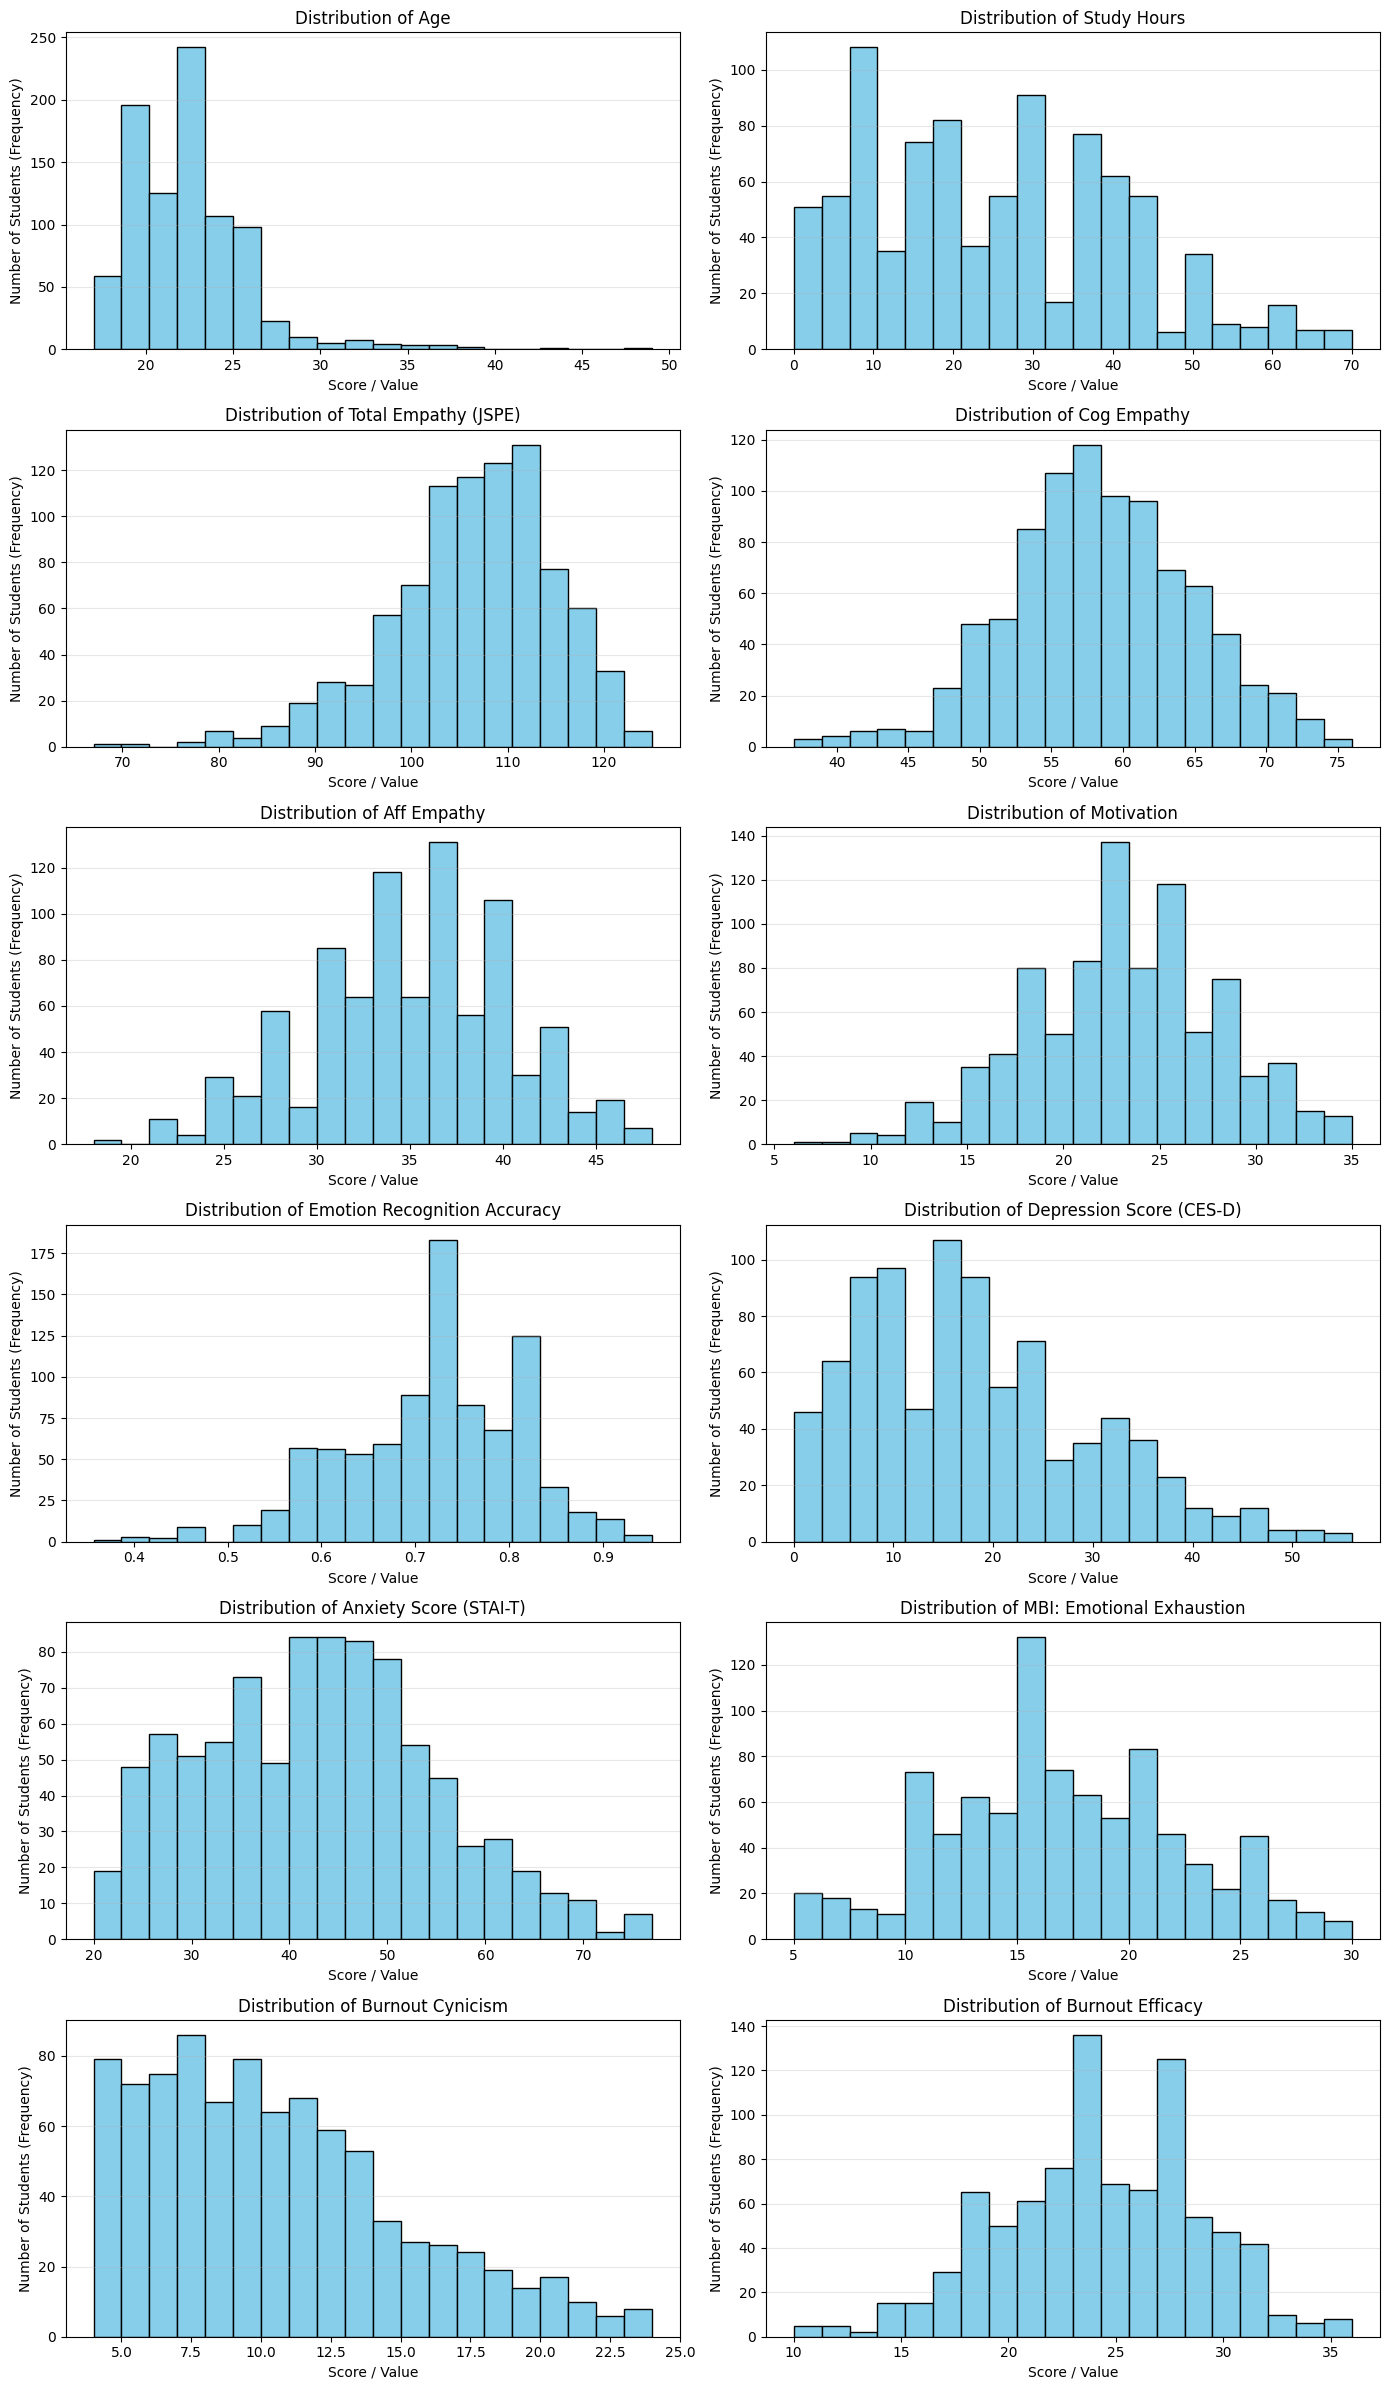

In [ ]:
title_map = {
    "total_empathy": "Total Empathy (JSPE)",
    "emotion_rec_acc": "Emotion Recognition Accuracy",
    "depression_score": "Depression Score (CES-D)",
    "anxiety_score": "Anxiety Score (STAI-T)",
    "burnout_exhaustion": "MBI: Emotional Exhaustion"
}

n_cols = 2
n_rows = math.ceil(len(numeric_vars) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_vars):
    axes[i].hist(
        df[col].dropna(),
        bins=20,              # adjust if needed (15–30 is typical)
        color='skyblue',
        edgecolor='black'
    )

    clean_title = title_map.get(col, col.replace('_', ' ').title())
    axes[i].set_title(f"Distribution of {clean_title}")
    axes[i].set_xlabel("Score / Value")
    axes[i].set_ylabel("Number of Students (Frequency)")
    axes[i].grid(axis='y', alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Distribution of Age:**
The age distribution was right-skewed, with most participants aged between 19 and 25 years.

A smaller number of older students were present, extending the upper tail of the distribution. This reflects the typical age structure of medical students, where we have many young students and few older ones

**Distribution of Study Hours:**
Study hours varied substantially, indicating differences in academic workload among students. Most students report moderate study hours and a smaller number report very high workloads.

**Distribution of Total Empathy:**
The distribution of total empathy (JSPE) scores was approximately normal, with most participants scoring within a moderate to high range. Very low or very high empathy scores are uncommon, this indicates meaningful variability in empathy levels without strong skewness or extreme values.

**Distribution of COG Empathy:**
The distribution looks fairly balanced, with a slight spread on both sides, not heavily skewed. Shows that most students have similar cognitive empathy scores, with only a few scoring much lower or higher than the rest.

**Distribution of Aff Empathy:**
Affective empathy scores are slightly skewed, suggesting that some students report higher affective empathy. This indicates individual differences in emotional responsiveness.

**Distribution of Academic Motivation:**
The distribution is generally high, while some decline in tail. Most participants report strong motivation. A smaller number of participants reported lower motivation, indicating some variability in academic engagement.

**Distribution of Emotion Recognition:**
The distribution of emotion recognition accuracy follows a near-normal bell curve, indicating a balanced spread of ability across the sample. Most medical students demonstrate high proficiency in identifying emotional cues, though a small subset of participants shows significantly lower scores (below 50%).

**Distribution of Depression(cesd):**
Depression scores shows a right-skewed distribution, with most participants reporting low symptom levels and a smaller group showing elevated depressive symptoms.

**Distribution of Anxiety Score(stai-t):**
Anxiety scores show moderate variability, with most students in the mid-range and fewer at the high end. This suggests different anxiety levels but not extreme.

**Distribution of Emotional Exhaustion(mbi-ex):**
Burnout exhaustion scores were widely distributed, with moderate average levels and a noticeable upper tail. This indicates that while many students experienced manageable levels of exhaustion, few reported high burnout.

**Distribution of Burnout Cynicism(mbi-cy):**
Cynicism scores is postively skewed,the student maintained a generally low level of cynicism, showing that while students might be Exhausted, they haven't yet reached the stage of burnout where they become "Cynical" or detached from their medical calling.

**Distribution of Burnout efficacy(mbi-ea):**
Burnout efficacy scores were relatively high overall, indicating that most participants maintained a sense of competence and effectiveness despite academic demands.

**categorical variables**

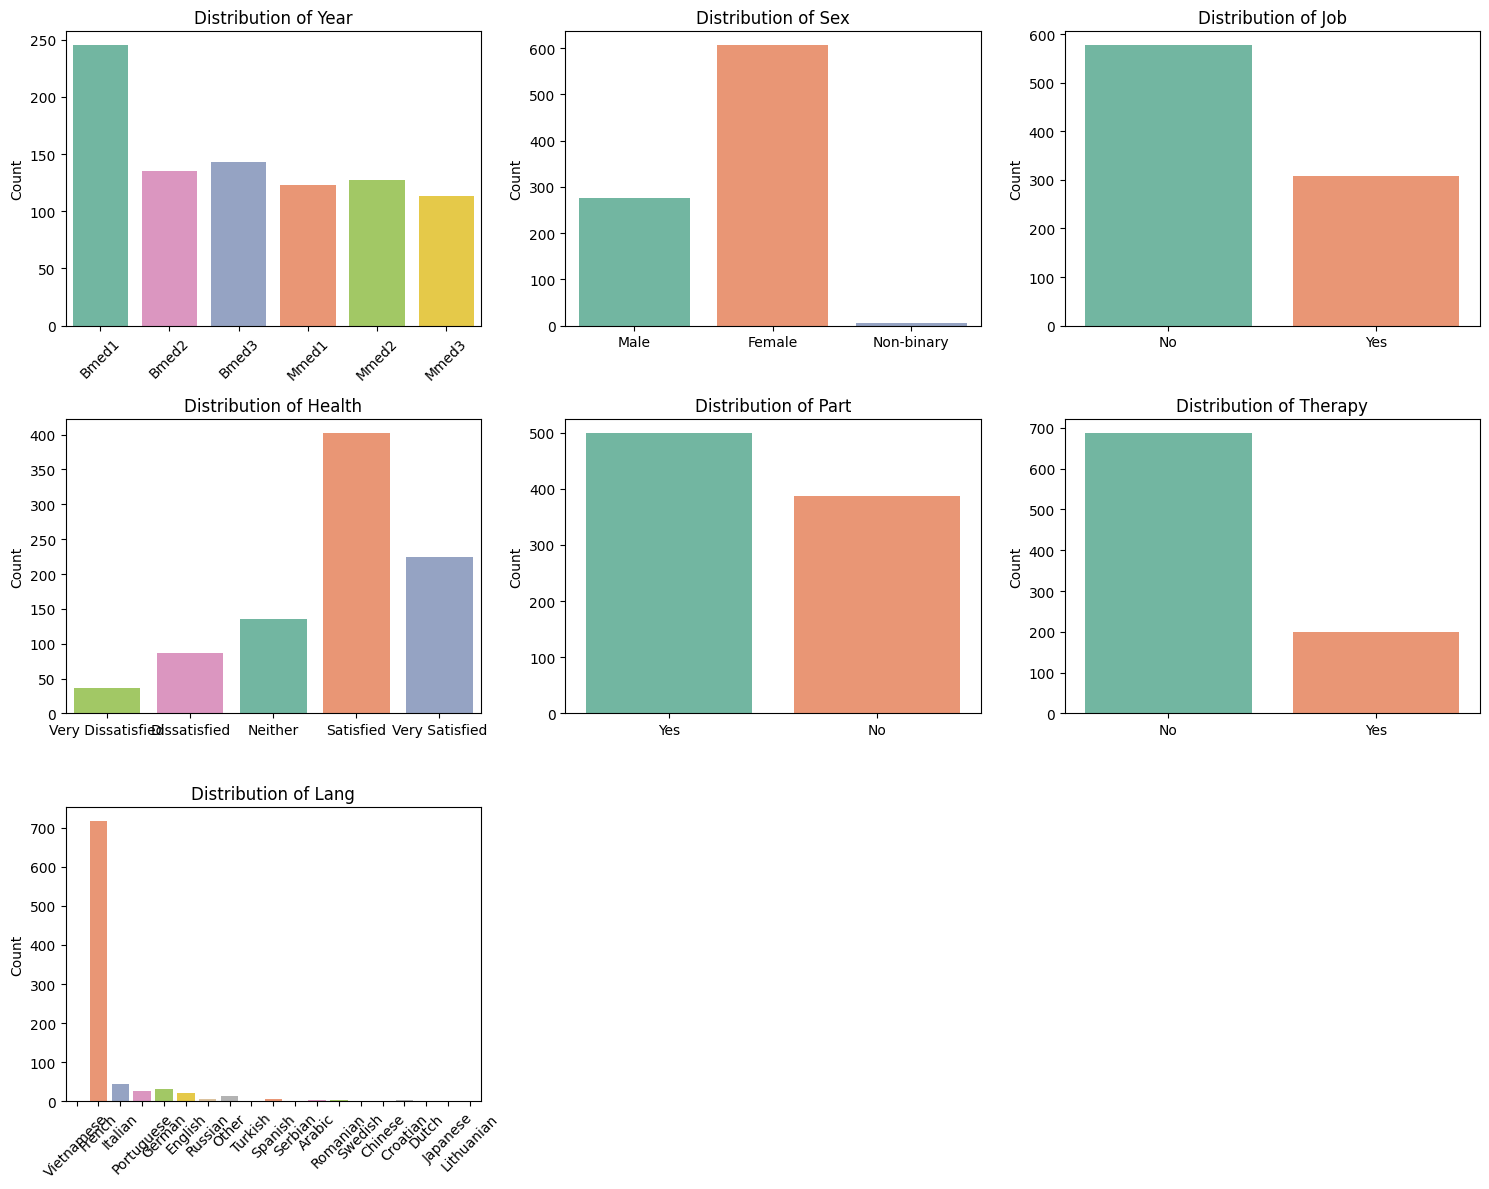

In [ ]:

labeled_categorical_vars = [
    'year_label', 'sex_label', 'job_label',
    'health_label', 'part_label', 'therapy_label', 'lang_label'
]

n_plots = len(labeled_categorical_vars)

n_cols = 3
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(labeled_categorical_vars):
    if col not in df.columns:
        continue

    ax = axes[i]

    order = None
    if col == 'year_label':
        order = ["Bmed1", "Bmed2", "Bmed3", "Mmed1", "Mmed2", "Mmed3"]
    elif col == 'health_label':
        order = ["Very Dissatisfied", "Dissatisfied", "Neither", "Satisfied", "Very Satisfied"]

    sns.countplot(
      data=df,
      x=col,
      hue=col,
      order=order,
      palette="Set2",
      legend=False,
      ax=ax
    )

    ax.set_title(f"Distribution of {col.replace('_label', '').title()}")
    ax.set_xlabel("")
    ax.set_ylabel("Count")

    if col in ['lang_label', 'year_label']:
        ax.tick_params(axis='x', rotation=45)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**Distribution of Year**
Participation is highest in Year 1 and slowly decrease in later years, which could indicate that early-career students feel more compelled to share their distress or simply have more time for surveys.

**Distribution of Sex**
The sample showed an uneven gender distribution and findings on psychological distress will largely reflect the experiences of female students.

**Distribution of Job**
Most students are not employed. Therefore, employment status may influence stress and burnout

**Distribution of Health**
Most students say they are Satisfied with their health (about 400 students)

**Distribution of Partners**
More students reported having a partner, around 500 of them.

**Distribution of Therapy**
The majority of students have not used therapy.

**Distribution of Language**
Almost all students listed French as their main language, with only a few students speaking other languages.

### **Box plots**

**Analysis of Burnout across demographic groups (Age, Year of study, Language, Sex)**

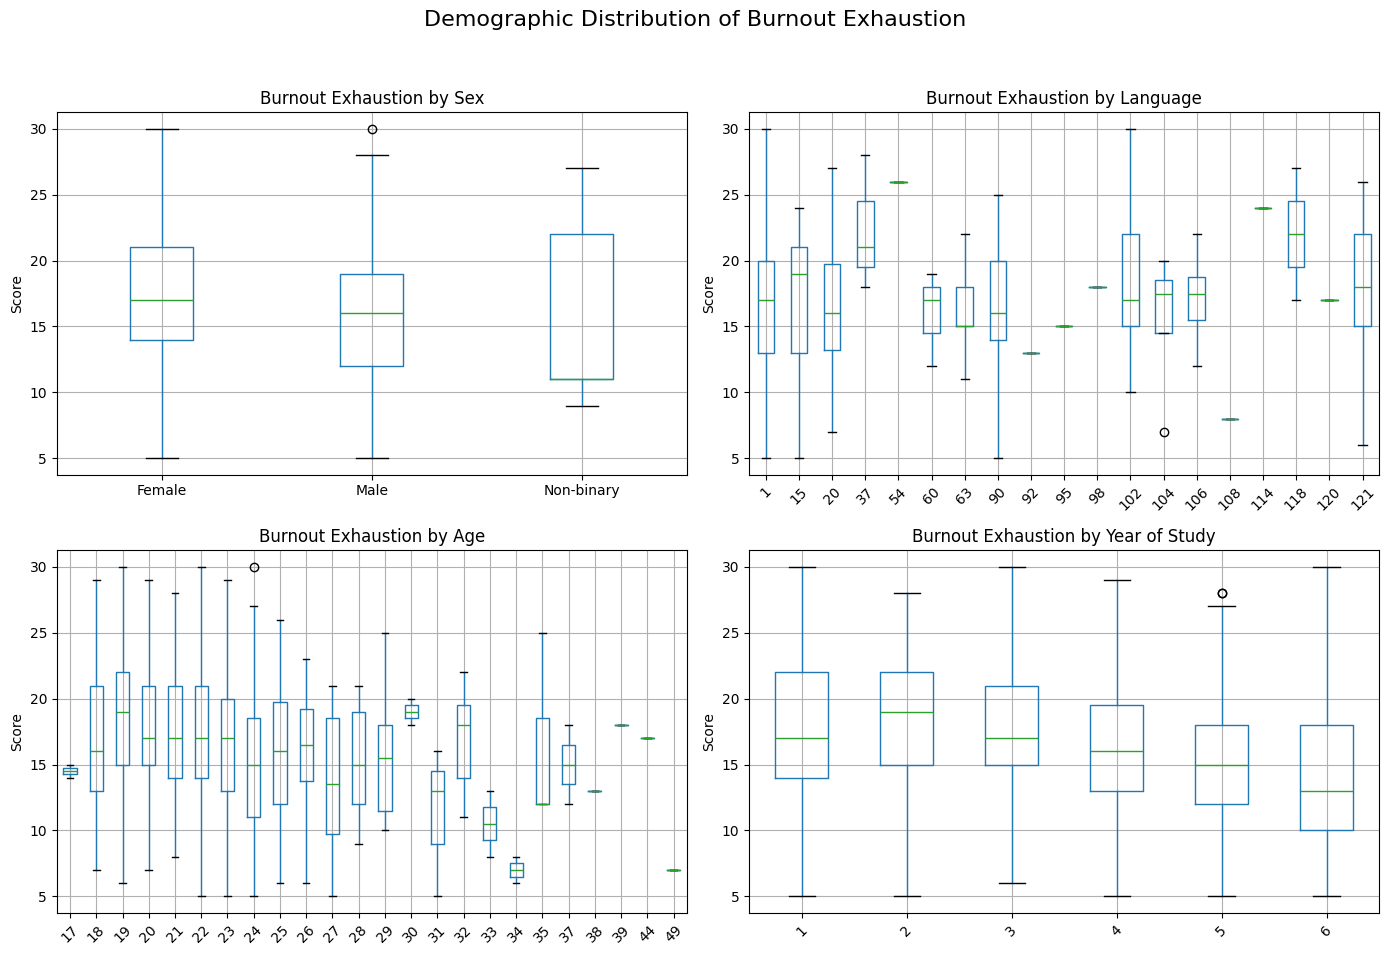

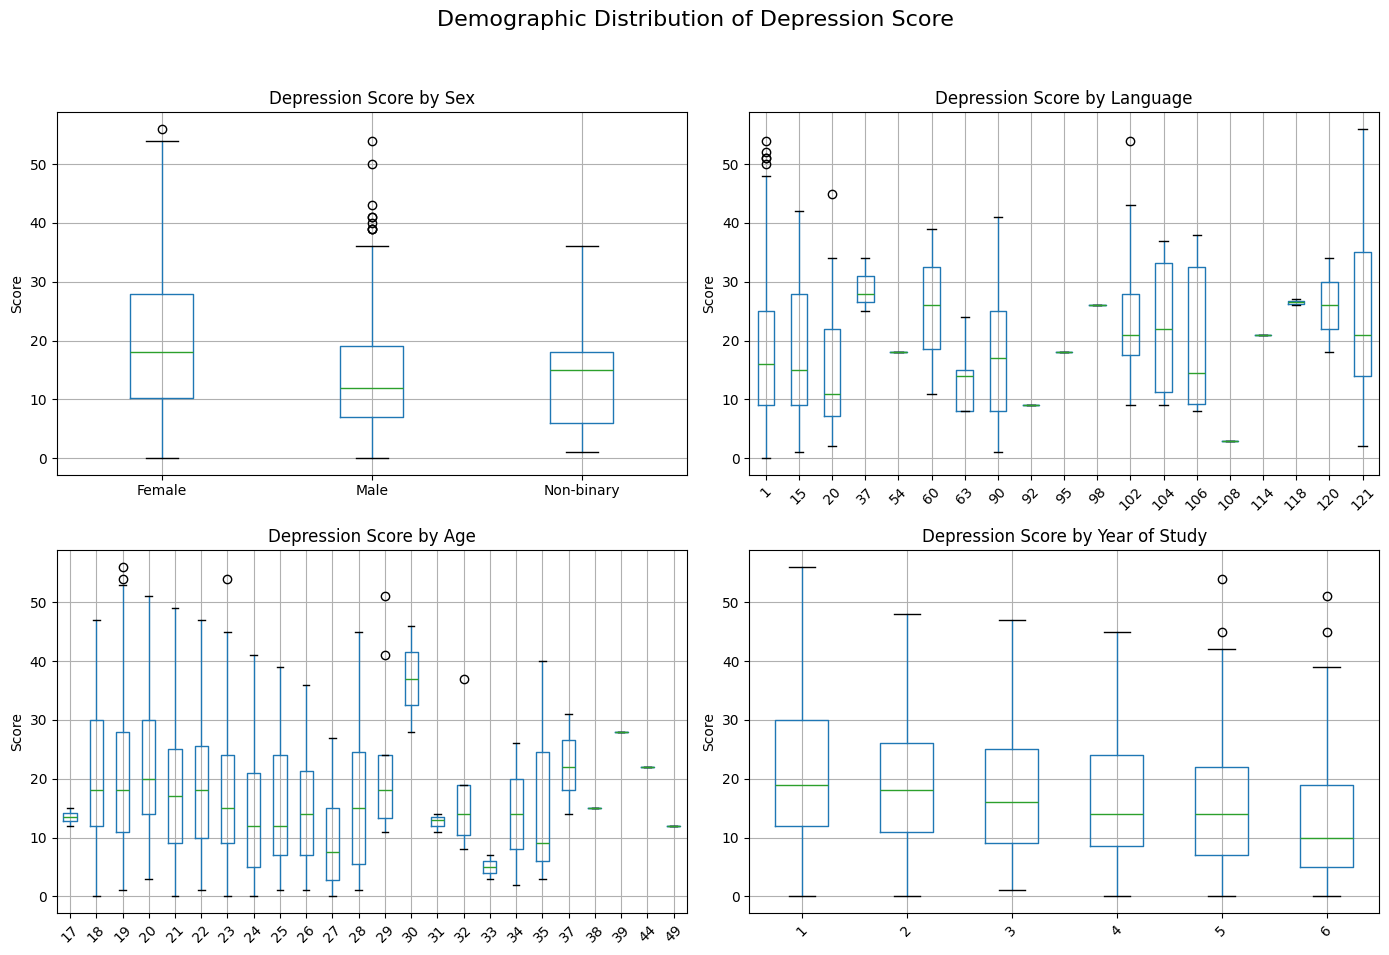

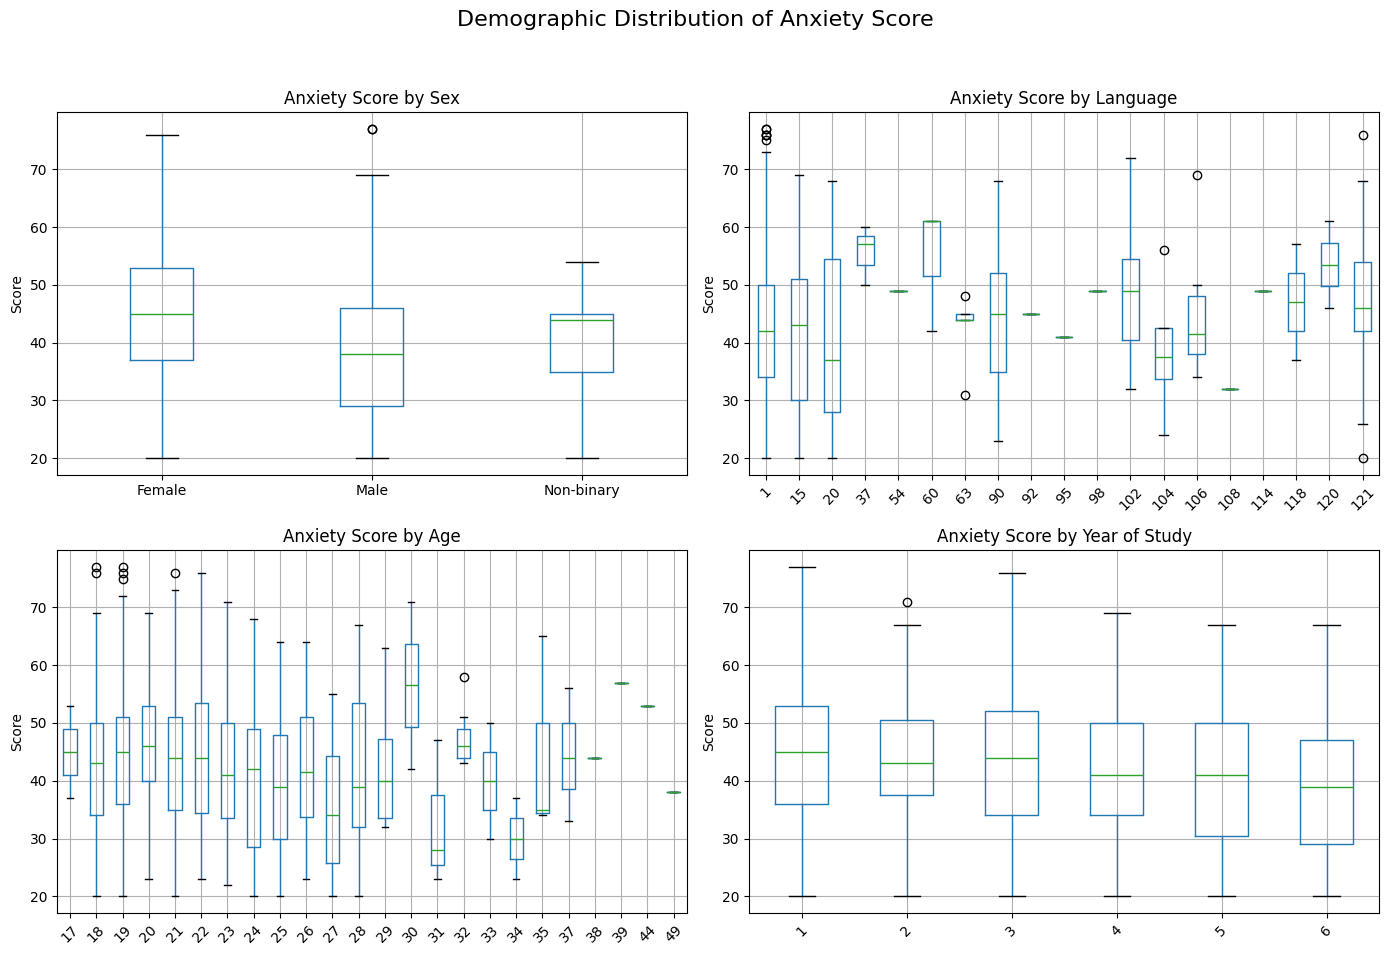

In [ ]:
# Analysis of Burnout across demographic groups (Age, Year of study, Language, Sex)
# fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# ax_list = axes.flatten()
# cols = ['sex_label', 'glang', 'age', 'year']
# titles = ['Sex', 'Language', 'Age', 'Year of Study']

# for i, col in enumerate(cols):
#     df.boxplot(column="burnout_exhaustion", by=col, ax=ax_list[i])
#     ax_list[i].set_title(f"Burnout by {titles[i]}")
#     ax_list[i].set_xlabel("")
#     ax_list[i].set_ylabel("MBI Exhaustion")
#     if col in ['glang', 'age', 'year']:
#         ax_list[i].tick_params(axis='x', rotation=45)

# plt.suptitle("Analysis of Burnout Across Demographic Groups", fontsize=16)
# plt.subplots_adjust(top=0.9)

# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.show()



# New code for more than one parameters
outcomes = ["burnout_exhaustion", "depression_score", "anxiety_score"]
demographics = ['sex_label', 'glang', 'age', 'year']
titles = ['Sex', 'Language', 'Age', 'Year of Study']

for outcome in outcomes:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    ax_list = axes.flatten()

    for i, col in enumerate(demographics):
        df.boxplot(column=outcome, by=col, ax=ax_list[i])
        ax_list[i].set_title(f"{outcome.replace('_', ' ').title()} by {titles[i]}")
        ax_list[i].set_xlabel("")
        ax_list[i].set_ylabel("Score")

        if col in ['glang', 'age', 'year']:
            ax_list[i].tick_params(axis='x', rotation=45)

    plt.suptitle(f"Demographic Distribution of {outcome.replace('_', ' ').title()}", fontsize=16)
    plt.subplots_adjust(top=0.9)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

**Burnout by Sex**

The distribution of burnout exhaustion scores shows that both male and female students exhibit a range of burnout levels. Median exhaustion appears slightly higher for females, but substantial overlap exists between sexes. Some extreme values indicate individuals with unusually high or low burnout. Overall, differences by sex are modest and variability within groups is considerable.

Interestingly, the single most exhausted person in this specific view is actually Male, shown by the outlier circle at the very top (score of 30).

The female scores are more packed toward the top without having a single detached outlier at 30, though their whiskers do reach that high

**Burnout by Language**

The distribution of burnout exhaustion scores varies across language groups, with some groups showing higher median levels than others.

However, several language groups contain very few observations, resulting in difficulty in interpreting relaibly.

Overlap in burnout scores across groups is obvious and can affect the model. Therefore we will merge the laguage groups of the minority for our ML models.

**Burnout by Age**

Students in their early 20s (ages 18 to 24) are mostly affected by burnout, it shows they have the highest levels of exhaustion and the widest range of scores.

Several young age groups (19, 21, 22, 23, and 24) have extreme stress and they are reaching the maximum exhaustion score of 30.

Older Students over the age of 30 generally report lower exhaustion levels, though there are much fewer older students in the study to compare. For example, 34-year-olds have really low scores.

**Burnout by Year of Study**

Burnout risk is concentrated in the first two years of study and the median exhaustion reaches peak in Year 2 and then gradually decreases as students progress toward Year 6.

**Study Hours Vs Burnout (Exhaustion)**

In [ ]:
df.groupby('sex')['depression_score'].mean()


,depression_score
sex,
1,14.003636
2,19.910891
3,15.200000


In [ ]:
# Subset relevant variables
cols = ['sex', 'age', 'year', 'glang', 'depression_score', 'anxiety_score']
df_sub = df[cols].copy()


In [ ]:
df_sub[['age', 'depression_score', 'anxiety_score']].describe()


,age,depression_score,anxiety_score
count,886.000000,886.000000,886.000000
mean,22.383747,18.050790,42.898420
std,3.300664,11.478731,11.978458
min,17.000000,0.000000,20.000000
25%,20.000000,9.000000,34.000000
50%,22.000000,16.000000,43.000000
75%,24.000000,25.000000,51.000000
max,49.000000,56.000000,77.000000


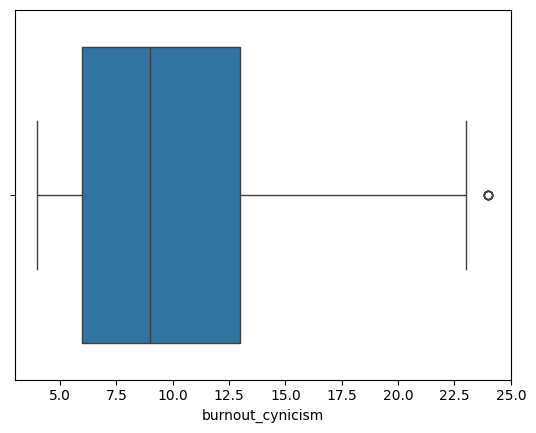

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["burnout_cynicism"])
plt.show()


**Check inconsistent values**

In [ ]:
df_sub[(df_sub['age'] < 16) | (df_sub['age'] > 40)]


,sex,age,year,glang,depression_score,anxiety_score
417,2,49,3,104,12,38
520,2,44,5,1,22,53


## **Outlier Detection**

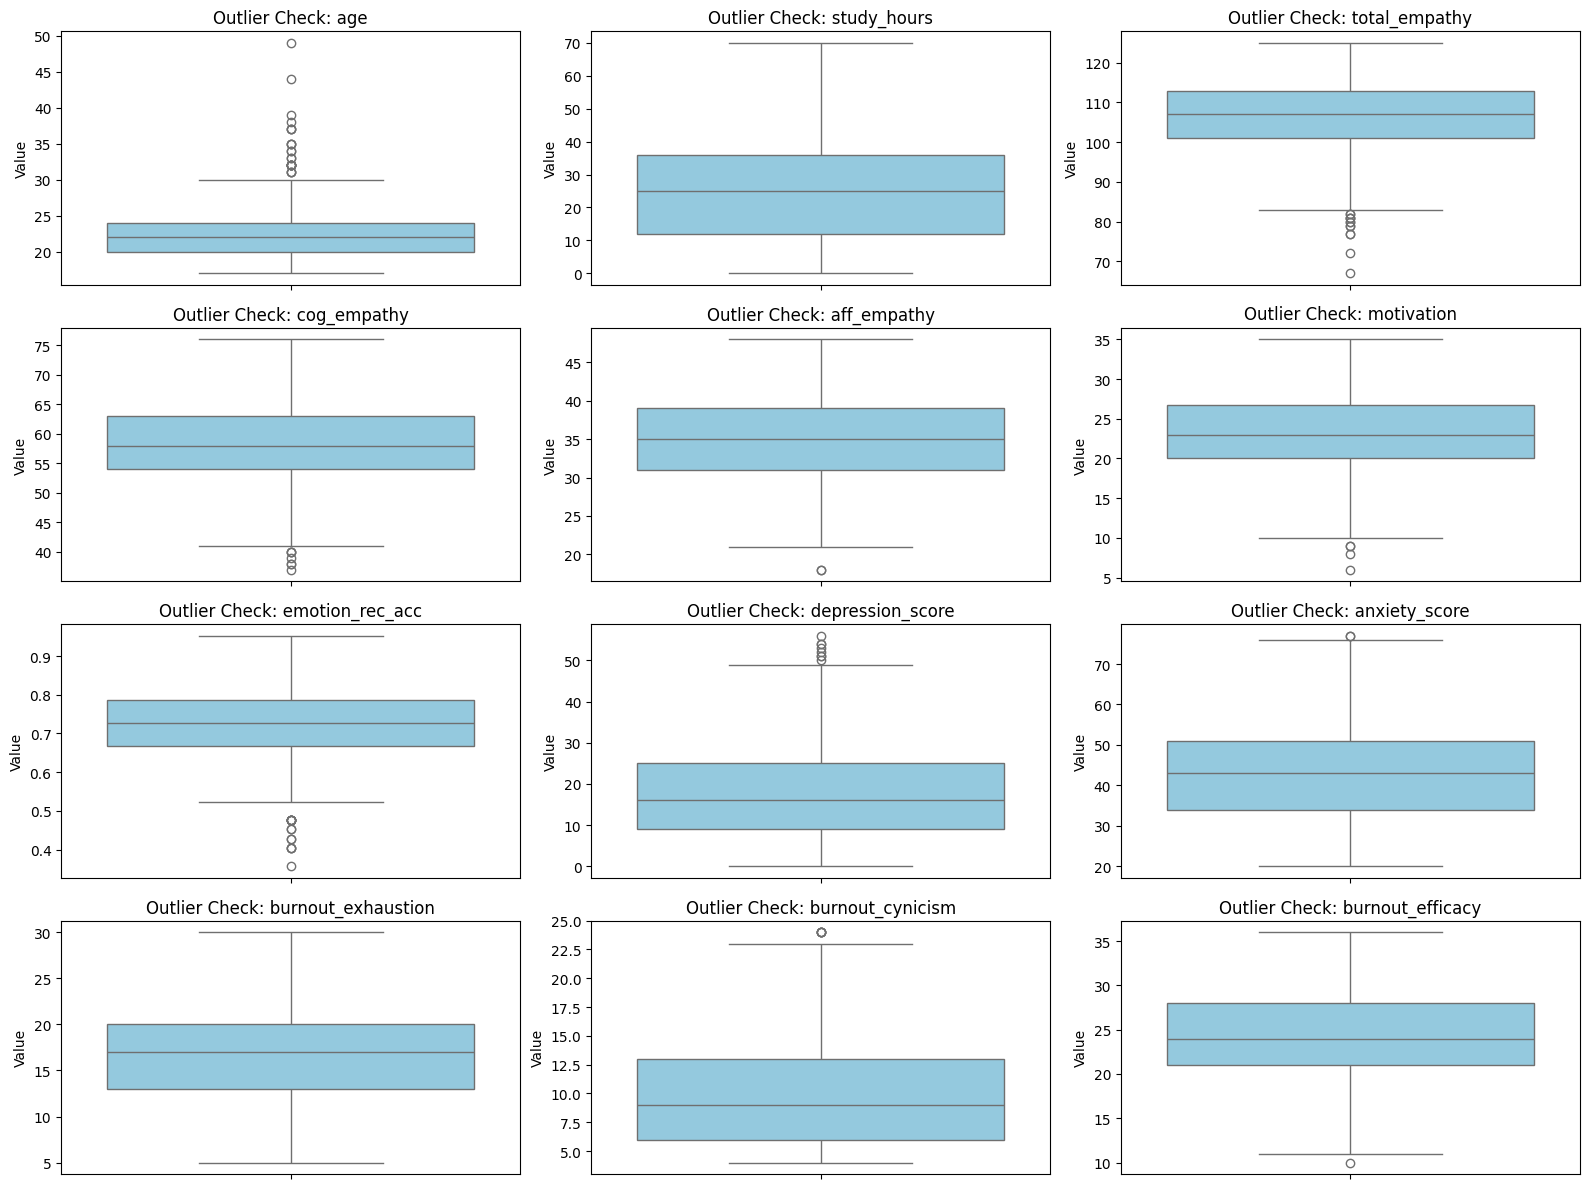

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(16, 12))

for i, col in enumerate(numeric_vars, 1):
    plt.subplot(4, 3, i) # 4 rows, 3 columns
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f"Outlier Check: {col}")
    plt.ylabel("Value")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

outlier_data = []

for col in numeric_vars:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    percentage = (outliers_count / len(df)) * 100

    outlier_data.append({
        'Variable': col,
        'Outlier Count': outliers_count,
        'Percentage (%)': round(percentage, 2)
    })
outlier_report = pd.DataFrame(outlier_data).sort_values(by='Percentage (%)', ascending=False)

print("--- Outlier Analysis ---")
print(outlier_report)

--- Outlier Analysis ---
              Variable  Outlier Count  Percentage (%)
0                  age             24            2.71
6      emotion_rec_acc             15            1.69
2        total_empathy             13            1.47
7     depression_score              8            0.90
3          cog_empathy              7            0.79
10    burnout_cynicism              5            0.56
5           motivation              4            0.45
4          aff_empathy              2            0.23
8        anxiety_score              2            0.23
11    burnout_efficacy              1            0.11
1          study_hours              0            0.00
9   burnout_exhaustion              0            0.00


**Viewing Outlier Rows**

In [ ]:
for i in numeric_vars:
  print(f"mean: {df[i].mean():.4f}, std: {df[i].std():.4f}")
  Q1 = df[i].quantile(0.25)
  Q3 = df[i].quantile(0.75)
  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  outliers = df[(df[i] < lower) | (df[i] > upper)]

  print(outliers[[i]])
  print("-"*50)

mean: 22.3837, std: 3.3007
     age
48    32
54    32
60    37
76    31
163   32
278   35
385   33
393   35
417   49
432   37
453   31
520   44
523   32
529   34
531   33
564   32
571   39
629   32
676   31
737   38
771   37
774   35
859   32
871   34
--------------------------------------------------
mean: 25.2889, std: 15.9279
Empty DataFrame
Columns: [study_hours]
Index: []
--------------------------------------------------
mean: 106.3747, std: 8.7840
     total_empathy
172             77
216             72
317             82
337             82
403             79
584             81
593             80
613             77
660             80
669             81
692             81
837             79
855             67
--------------------------------------------------
mean: 58.5260, std: 6.5703
     cog_empathy
170           40
206           38
306           40
393           39
577           40
584           37
821           38
--------------------------------------------------
mean: 34.7

Age Capping

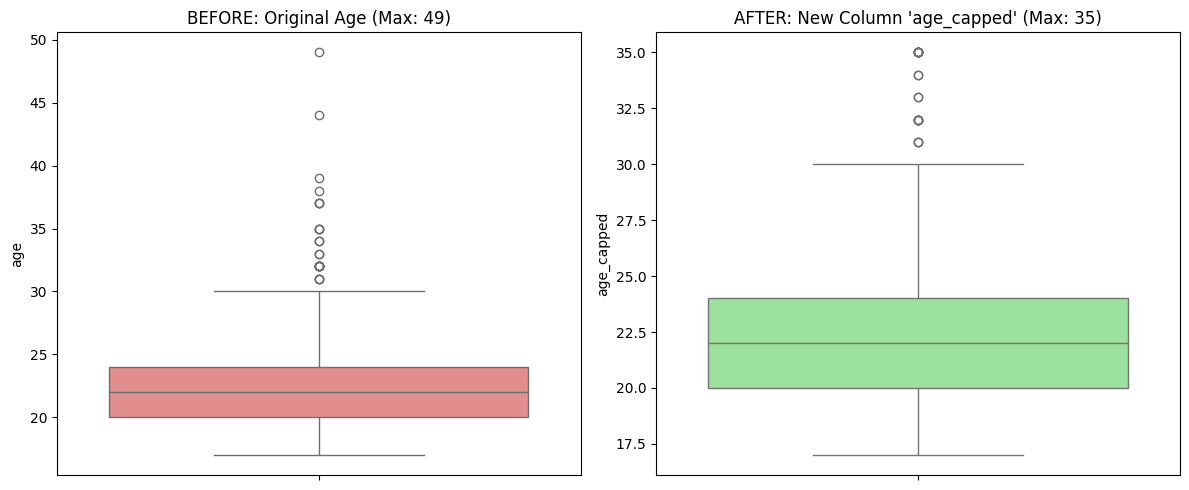

Analysis: Capped 7 students at age 35.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the new column so we don't lose the original 'age'
df['age_capped'] = df['age'].clip(upper=35)

age_before_max = df['age'].max()
age_after_max = df['age_capped'].max()

plt.figure(figsize=(12, 5))

# Plot 1: Original Age
plt.subplot(1, 2, 1)
sns.boxplot(y=df['age'], color='lightcoral')
plt.title(f"BEFORE: Original Age (Max: {age_before_max})")

# Plot 2: Capped Age (New Column)
plt.subplot(1, 2, 2)
sns.boxplot(y=df['age_capped'], color='lightgreen')
plt.title(f"AFTER: New Column 'age_capped' (Max: {age_after_max})")

plt.tight_layout()
plt.show()

print(f"Analysis: Capped { (df['age'] > 35).sum() } students at age 35.")

decided to cap Age because Machine Learning models are sensitive to extreme numbers. By bringing those 24 students closer to the group mean, I ensured the model focuses on the typical patterns of medical students in Switzerland, rather than being distracted by a single 49-year-old outlier.

**Language**:

Data have a very heavy imbalance: French (code 1) has 717 speakers, while most other languages have fewer than 10. To perform a meaningful analysis, need to group these infrequent languages so Machine Learning model doesn't try to find patterns in groups of only 1 or 2 people.

*we should decide wether to keep mother-tongue language as a feature or not. But we have to threshold the languages and group the less common ones as "others".*

In [ ]:
# Check how many students speak each language
print(df['glang'].value_counts())


glang
1      717
90      45
15      31
102     27
20      22
121     13
106      6
63       5
104      4
60       3
37       3
120      2
118      2
108      1
114      1
54       1
98       1
92       1
95       1
Name: count, dtype: int64


/tmp/ipykernel_255/4226125903.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, y='lang_label',


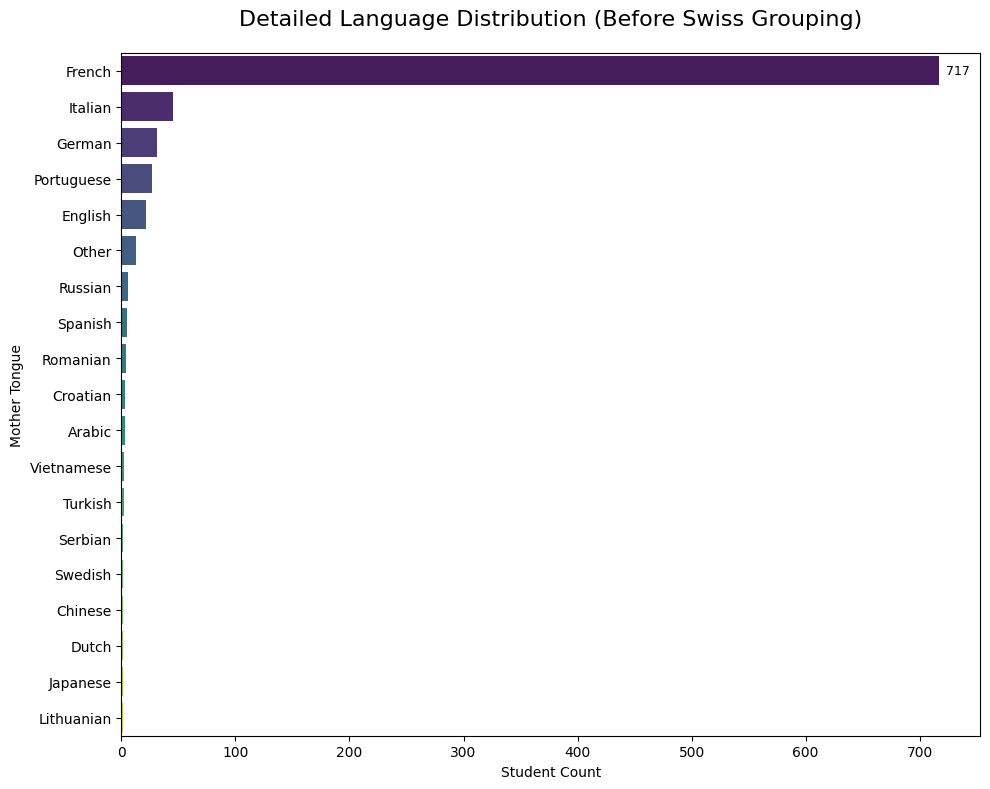

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))

ax = sns.countplot(data=df, y='lang_label',
                   order=df['lang_label'].value_counts().index,
                   palette='viridis')

ax.bar_label(ax.containers[0], padding=5, fontsize=9)
plt.title("Detailed Language Distribution (Before Swiss Grouping)", fontsize=16, pad=20)
plt.xlabel("Student Count", fontsize=10)
plt.ylabel("Mother Tongue", fontsize=10)

plt.tight_layout()
plt.show()


Looking at the raw data, we see a 'Long Tail' effect. French dominates with 717 speakers, while 15 other languages have fewer than 5 speakers each. This imbalance would confuse a Machine Learning model."

Strategic Grouping

In [ ]:
df['language_name'] = df['glang'].map(language_map)
def swiss_grouping(lang):
    if lang in ['French', 'German', 'Italian']:
        return lang
    else:
        return 'Other'

df['lang_final'] = df['language_name'].apply(swiss_grouping)
print("--- Swiss-Aligned Language Groups ---")
print(df['lang_final'].value_counts())

--- Swiss-Aligned Language Groups ---
lang_final
French     717
Other       93
Italian     45
German      31
Name: count, dtype: int64


Since this study was conducted in Switzerland, it was vital to preserve the distinction between the national languages—French, German, and Italian—as these reflect the students' cultural and academic backgrounds

/tmp/ipykernel_255/1128853482.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='lang_final',


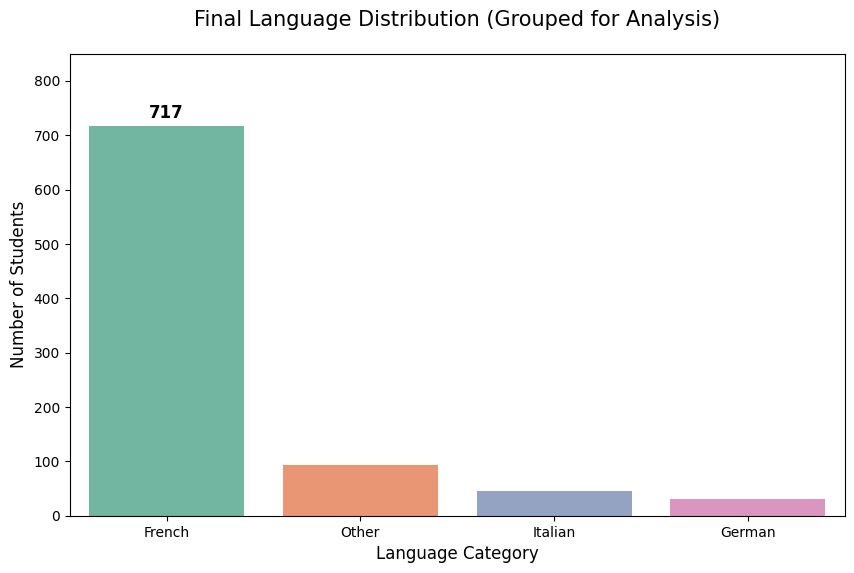

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
df['lang_final'] = df['language_name'].apply(lambda x: x if x in ['French', 'German', 'Italian'] else 'Other')

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='lang_final',
                   order=['French', 'Other', 'Italian', 'German'],
                   palette='Set2')

ax.bar_label(ax.containers[0], padding=3, fontsize=12, fontweight='bold')
plt.title("Final Language Distribution (Grouped for Analysis)", fontsize=15, pad=20)
plt.xlabel("Language Category", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)
plt.ylim(0, 850)

plt.show()

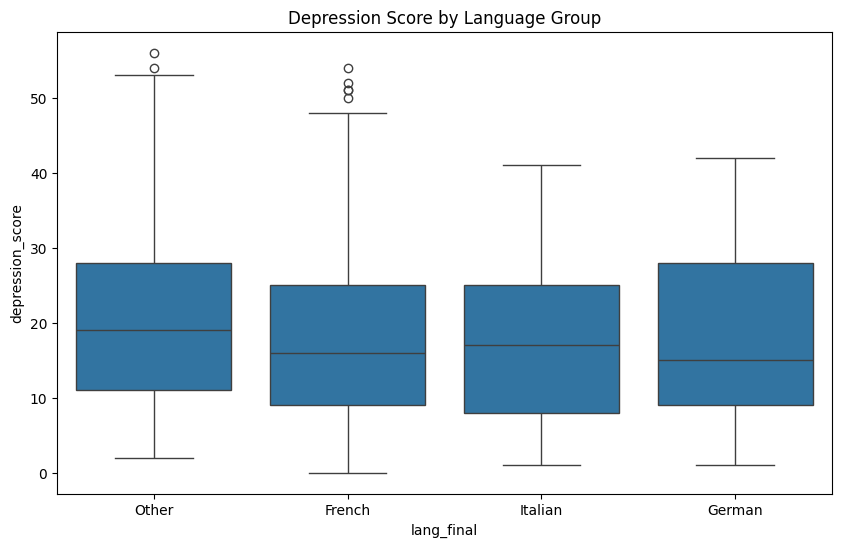

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='lang_final', y='depression_score')
plt.title("Depression Score by Language Group")
plt.show()

It shows that the median depression scores across French, German, Italian, and Other are very similar.

Language reflects the student's background, it is not a major factor in predicting mental health compared to psychological traits like anxiety.

**Sex**

Non-binary has only 5 samples, so it's better to drop those rows

In [ ]:
df = df[df["sex"] != 3].reset_index(drop=True)
df.shape

(881, 30)

In [ ]:
df.columns

Index(['id', 'age', 'year', 'sex', 'glang', 'part', 'job', 'study_hours',
       'health', 'therapy', 'total_empathy', 'cog_empathy', 'aff_empathy',
       'motivation', 'emotion_rec_acc', 'depression_score', 'anxiety_score',
       'burnout_exhaustion', 'burnout_cynicism', 'burnout_efficacy',
       'sex_label', 'job_label', 'health_label', 'part_label', 'therapy_label',
       'year_label', 'lang_label', 'age_capped', 'language_name',
       'lang_final'],
      dtype='object')

**Exploratory Insights**

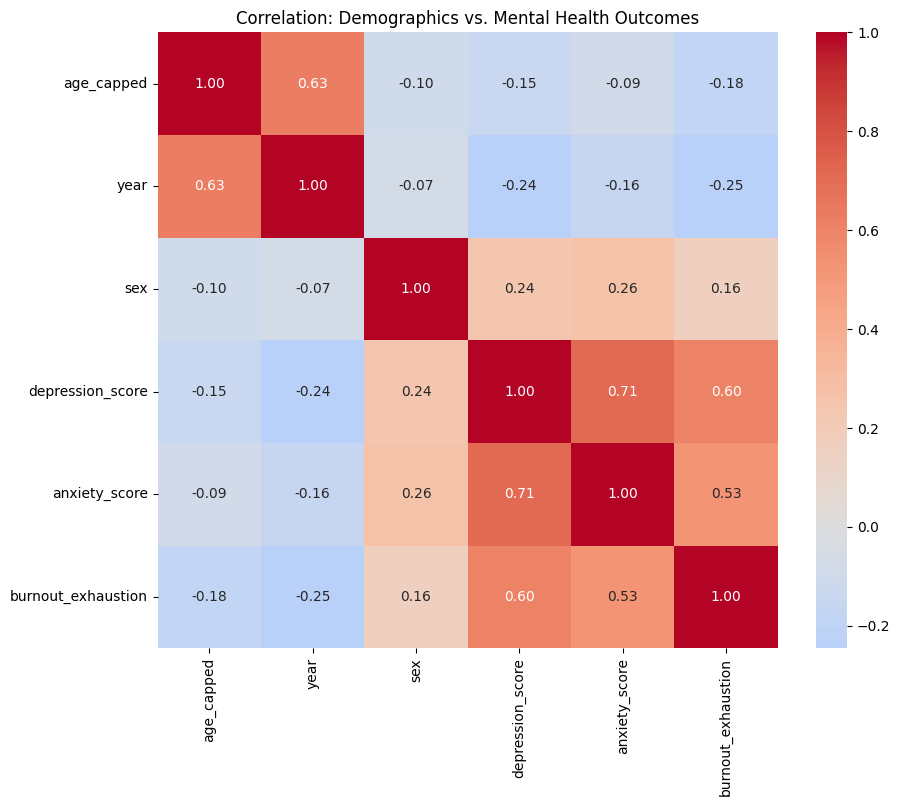

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Create the new column for Age (as you requested)
df['age_capped'] = df['age'].clip(upper=35)

# 2. Select the columns for the Research Question
research_cols = ['age_capped', 'year', 'sex', 'lang_label',
                 'depression_score', 'anxiety_score', 'burnout_exhaustion']

# 3. Filter to only numeric data to avoid the ValueError
numeric_df = df[research_cols].select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title("Correlation: Demographics vs. Mental Health Outcomes")
plt.show()

Correlation Matrix

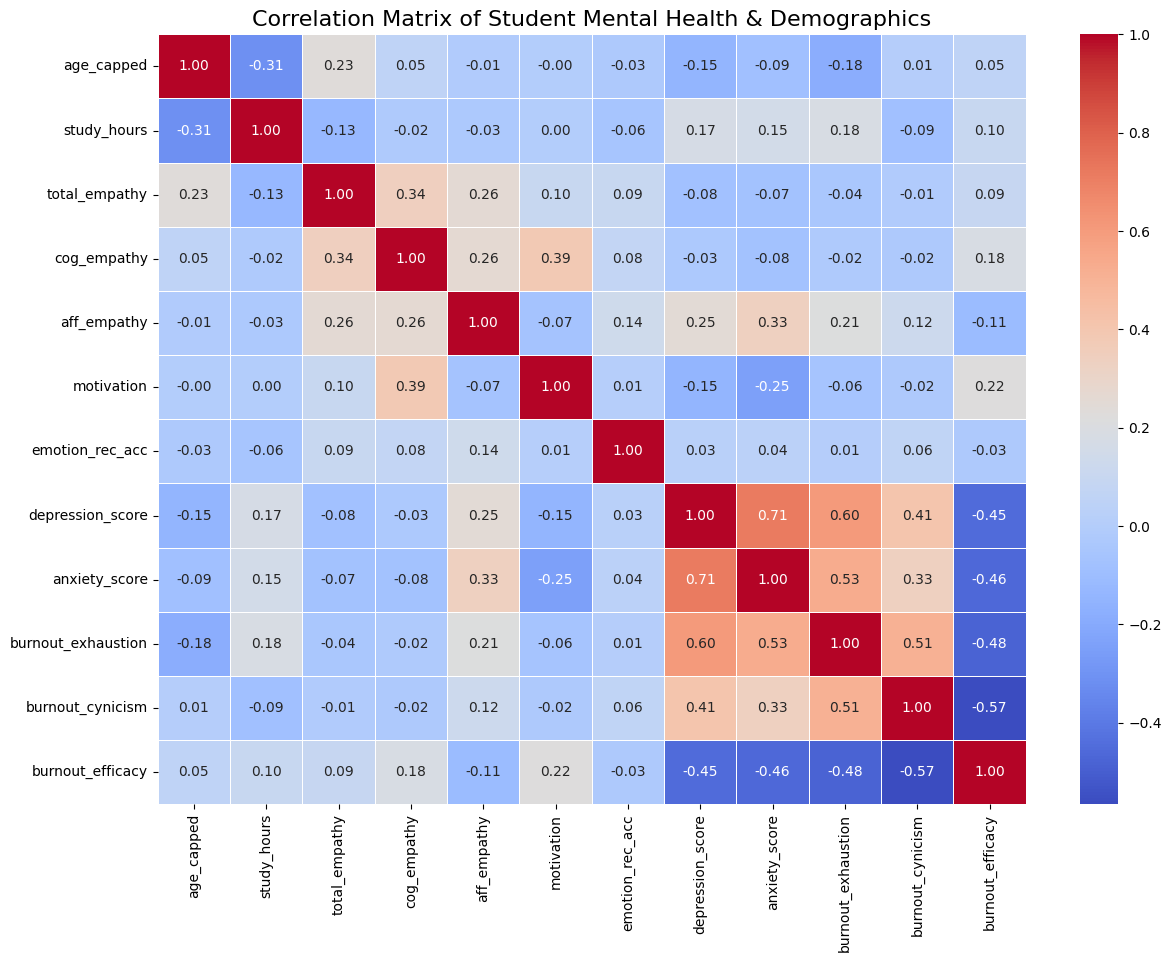

--- Top Correlations with Depression Score ---
depression_score      1.000000
anxiety_score         0.714492
burnout_exhaustion    0.604933
burnout_cynicism      0.412181
aff_empathy           0.252865
study_hours           0.172270
emotion_rec_acc       0.025635
cog_empathy          -0.031544
total_empathy        -0.077324
age_capped           -0.146430
motivation           -0.148092
burnout_efficacy     -0.453972
Name: depression_score, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
numeric_vars = [
    "age_capped", "study_hours", "total_empathy", "cog_empathy", "aff_empathy",
    "motivation", "emotion_rec_acc", "depression_score", "anxiety_score",
    "burnout_exhaustion", "burnout_cynicism", "burnout_efficacy"
]
corr_matrix = df[numeric_vars].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix of Student Mental Health & Demographics", fontsize=16)
plt.show()

print("--- Top Correlations with Depression Score ---")
print(corr_matrix['depression_score'].sort_values(ascending=False))

**Chi Square Test of Independence**

In [ ]:
from scipy.stats import chi2_contingency

cols = ['year', 'health', 'therapy', 'part', 'job', 'sex', 'lang_final']
for i in range(len(cols)):
  for j in range(i, len(cols)):
    if i != j:
      print(f"{cols[i]} and {cols[j]}")
      contingency_table = pd.crosstab(df[cols[i]], df[cols[j]])

      # print("Contingency Table with Frequencies:")
      # print(contingency_table)
      # print("-"*60)

      # row percentages
      row_percentages = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100

      # print("\nRow Percentages:")
      # print(row_percentages)
      # print("-"*60)

      # chi-square test
      chi2, p, dof, expected = chi2_contingency(contingency_table)

      print(f"\nChi-squared value: {chi2:.4f}")
      print(f"P-value: {p}")
      print(f"Degrees of freedom: {dof:.4f}")

      percentage_low_expected = (expected < 5).sum().sum() / (expected.shape[0] * expected.shape[1]) * 100
      print(f"Percentage of cells with expected counts less than 5: {percentage_low_expected:.4f}%")
      print("-"*60)


year and health

Chi-squared value: 21.0647
P-value: 0.39333398161305916
Degrees of freedom: 20.0000
Percentage of cells with expected counts less than 5: 6.6667%
------------------------------------------------------------
year and therapy

Chi-squared value: 3.9139
P-value: 0.5618821059213162
Degrees of freedom: 5.0000
Percentage of cells with expected counts less than 5: 0.0000%
------------------------------------------------------------
year and part

Chi-squared value: 28.9315
P-value: 2.3916228340215242e-05
Degrees of freedom: 5.0000
Percentage of cells with expected counts less than 5: 0.0000%
------------------------------------------------------------
year and job

Chi-squared value: 72.1496
P-value: 3.656125341478918e-14
Degrees of freedom: 5.0000
Percentage of cells with expected counts less than 5: 0.0000%
------------------------------------------------------------
year and sex

Chi-squared value: 7.9172
P-value: 0.16085822673909642
Degrees of freedom: 5.0000
Percentage o

In [ ]:
for col in cols:
  print(df.groupby(col)['depression_score'].mean())
  print("-"*50)

year
1    21.946721
2    18.962963
3    17.636364
4    16.401639
5    15.436508
6    13.819820
Name: depression_score, dtype: float64
--------------------------------------------------
health
1    17.111111
2    28.781609
3    24.044776
4    17.114713
5    12.161435
Name: depression_score, dtype: float64
--------------------------------------------------
therapy
0    16.430454
1    23.712121
Name: depression_score, dtype: float64
--------------------------------------------------
part
0    19.489529
1    16.977956
Name: depression_score, dtype: float64
--------------------------------------------------
job
0    18.581882
1    17.104235
Name: depression_score, dtype: float64
--------------------------------------------------
sex
1    14.003636
2    19.910891
Name: depression_score, dtype: float64
--------------------------------------------------
lang_final
French     17.732493
German     17.677419
Italian    17.204545
Other      21.206522
Name: depression_score, dtype: float64
--------

In [ ]:
for col in cols:
  print(df.groupby(col)['anxiety_score'].mean())
  print("-"*50)

year
1    45.290984
2    43.740741
3    43.384615
4    41.655738
5    41.134921
6    39.504505
Name: anxiety_score, dtype: float64
--------------------------------------------------
health
1    39.833333
2    52.287356
3    48.888060
4    42.528678
5    36.869955
Name: anxiety_score, dtype: float64
--------------------------------------------------
therapy
0    41.038067
1    49.398990
Name: anxiety_score, dtype: float64
--------------------------------------------------
part
0    43.937173
1    42.136273
Name: anxiety_score, dtype: float64
--------------------------------------------------
job
0    43.461672
1    41.899023
Name: anxiety_score, dtype: float64
--------------------------------------------------
sex
1    38.272727
2    45.024752
Name: anxiety_score, dtype: float64
--------------------------------------------------
lang_final
French     42.525210
German     42.870968
Italian    43.000000
Other      45.934783
Name: anxiety_score, dtype: float64
-----------------------------

In [ ]:
for col in cols:
  print(df.groupby(col)['burnout_exhaustion'].mean())
  print(df.groupby(col)['burnout_cynicism'].mean())
  print(df.groupby(col)['burnout_efficacy'].mean())

  print("-"*50)

year
1    17.704918
2    18.466667
3    17.888112
4    16.508197
5    15.269841
6    14.099099
Name: burnout_exhaustion, dtype: float64
year
1     9.975410
2     9.037037
3     9.783217
4    10.598361
5    11.055556
6    10.171171
Name: burnout_cynicism, dtype: float64
year
1    24.204918
2    24.525926
3    24.139860
4    24.057377
5    24.071429
6    24.414414
Name: burnout_efficacy, dtype: float64
--------------------------------------------------
health
1    16.222222
2    20.643678
3    18.850746
4    16.942643
5    14.233184
Name: burnout_exhaustion, dtype: float64
health
1    10.138889
2    12.137931
3    11.276119
4     9.895262
5     8.825112
Name: burnout_cynicism, dtype: float64
health
1    24.861111
2    21.609195
3    22.895522
4    24.229426
5    25.955157
Name: burnout_efficacy, dtype: float64
--------------------------------------------------
therapy
0    16.387994
1    18.590909
Name: burnout_exhaustion, dtype: float64
therapy
0     9.698389
1    11.333333
Name: burnou

**Scatter Plot for Anxiety vs. Depression**

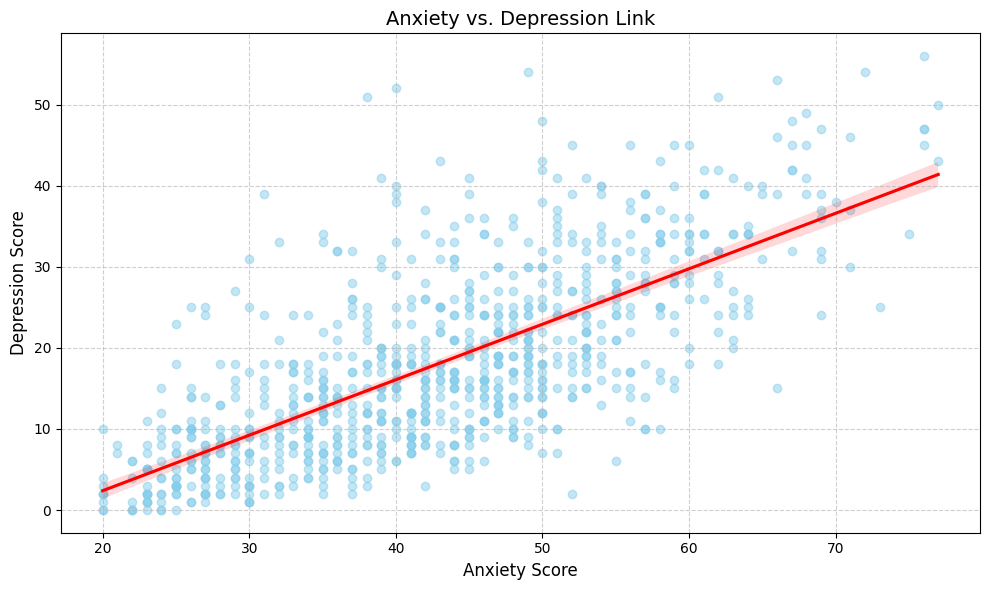

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='anxiety_score', y='depression_score',
            scatter_kws={'alpha':0.5, 'color':'skyblue'},
            line_kws={'color':'red'})
plt.title("Anxiety vs. Depression Link", fontsize=14)
plt.xlabel("Anxiety Score", fontsize=12)
plt.ylabel("Depression Score", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## **Check for Imbalance**

**Results in categorical features:**

- sex: non-binary (3) is extremely rare, only 5 people are non-binary -> drop the rows
- glang: Extremely imbalanced
- therapy: mild imbalance
- health: shouldn't be treated as categorical, it's an ordinal numeric


In [ ]:
for feat in categorical_vars:
  print(df[feat].value_counts())
  print()

year
1    244
3    143
2    135
5    126
4    122
6    111
Name: count, dtype: int64

sex
2    606
1    275
Name: count, dtype: int64

glang
1      714
90      44
15      31
102     27
20      22
121     13
106      6
104      4
63       4
60       3
37       3
120      2
118      2
108      1
114      1
54       1
98       1
92       1
95       1
Name: count, dtype: int64

part
1    499
0    382
Name: count, dtype: int64

job
0    574
1    307
Name: count, dtype: int64

health
4    401
5    223
3    134
2     87
1     36
Name: count, dtype: int64

therapy
0    683
1    198
Name: count, dtype: int64



In [ ]:
numeric_cols = ["age", "study_hours", "total_empathy", "cog_empathy",
                "aff_empathy", "motivation", "emotion_rec_acc"]
df[numeric_cols].describe()

,age,study_hours,total_empathy,cog_empathy,aff_empathy,motivation,emotion_rec_acc
count,881.000000,881.000000,881.000000,881.000000,881.000000,881.000000,881.000000
mean,22.372304,25.373439,106.331442,58.511918,34.765040,23.147560,0.719934
std,3.299429,15.923330,8.764548,6.581838,5.372316,4.983019,0.093371
min,17.000000,0.000000,67.000000,37.000000,18.000000,6.000000,0.357143
25%,20.000000,12.000000,101.000000,54.000000,31.000000,20.000000,0.666667
50%,22.000000,25.000000,107.000000,58.000000,35.000000,23.000000,0.714286
75%,24.000000,36.000000,113.000000,63.000000,39.000000,26.000000,0.785714
max,49.000000,70.000000,125.000000,76.000000,48.000000,35.000000,0.952381


**Results in labels:**

- depression: most students have low depression scores, fewer have high ones.

In [ ]:
labels = ["depression_score", "anxiety_score", "burnout_exhaustion",
          "burnout_cynicism", "burnout_efficacy"]

array([[<Axes: title={'center': 'depression_score'}>,
        <Axes: title={'center': 'anxiety_score'}>],
       [<Axes: title={'center': 'burnout_exhaustion'}>,
        <Axes: title={'center': 'burnout_cynicism'}>],
       [<Axes: title={'center': 'burnout_efficacy'}>, <Axes: >]],
      dtype=object)

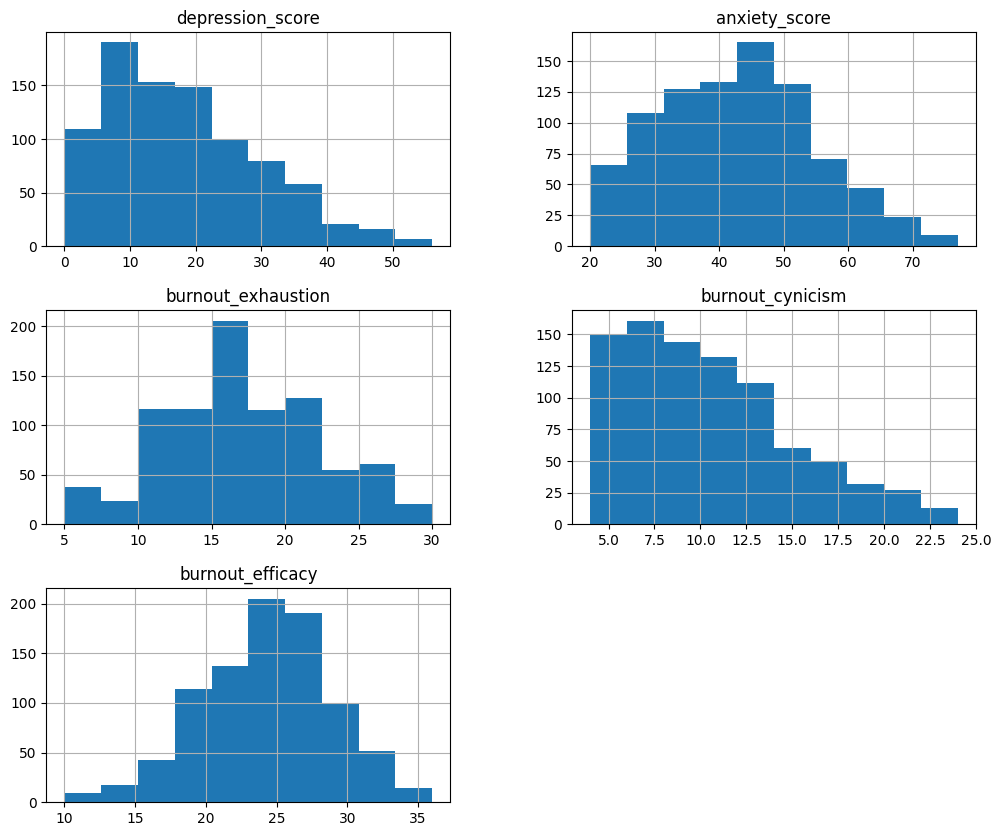

In [ ]:
df[labels].describe()
df[labels].hist(figsize=(12,10))


The correlation between these features are not very high, so we can keep both and not merge.

In [ ]:
df[['total_empathy','cog_empathy','aff_empathy']].corr()


,total_empathy,cog_empathy,aff_empathy
total_empathy,1.000000,0.342455,0.259767
cog_empathy,0.342455,1.000000,0.260118
aff_empathy,0.259767,0.260118,1.000000


# **2. Machine Learning**

## **One-hot Encoding**

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(df[["lang_final"]])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(["lang_final"]))

df_encoded = pd.concat([df, one_hot_df], axis=1)

df_encoded = df_encoded.drop(["lang_final"], axis=1)
df_encoded


,id,age,year,sex,glang,part,job,study_hours,health,therapy,...,part_label,therapy_label,year_label,lang_label,age_capped,language_name,lang_final_French,lang_final_German,lang_final_Italian,lang_final_Other
0,2,18,1,1,120,1,0,56,3,0,...,Yes,No,Bmed1,Vietnamese,18,Vietnamese,0.0,0.0,0.0,1.0
1,4,26,4,1,1,1,0,20,4,0,...,Yes,No,Mmed1,French,26,French,1.0,0.0,0.0,0.0
2,9,21,3,2,1,0,0,36,3,0,...,No,No,Bmed3,French,21,French,1.0,0.0,0.0,0.0
3,10,21,2,2,1,0,1,51,5,0,...,No,No,Bmed2,French,21,French,1.0,0.0,0.0,0.0
4,13,21,3,1,1,1,0,22,4,0,...,Yes,No,Bmed3,French,21,French,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876,1781,21,2,1,1,1,0,45,3,0,...,Yes,No,Bmed2,French,21,French,1.0,0.0,0.0,0.0
877,1785,20,2,2,1,0,0,13,3,0,...,No,No,Bmed2,French,20,French,1.0,0.0,0.0,0.0
878,1787,19,1,1,1,0,0,50,5,0,...,No,No,Bmed1,French,19,French,1.0,0.0,0.0,0.0
879,1789,24,5,2,1,0,0,20,2,1,...,No,Yes,Mmed2,French,24,French,1.0,0.0,0.0,0.0


In [ ]:
df_encoded.iloc[0]

,0
id,2
age,18
year,1
sex,1
glang,120
part,1
job,0
study_hours,56
health,3
therapy,0


In [ ]:
df_encoded = df_encoded.drop(columns=["sex_label", "job_label", "health_label", "part_label", "glang",
                                      "therapy_label", "year_label", "lang_label", "language_name"])

In [ ]:
df_encoded["sex"] = df_encoded["sex"].map({1: 0, 2: 1})

**Adding categories**

> CES-D cut-offs of 16 for men and 21 for women were
well validated.

In [ ]:
df_encoded["depression_category"] = 0

df_encoded.loc[(df_encoded["sex"] == 0) & (df_encoded["depression_score"] >= 16), "depression_category"] = 1
df_encoded.loc[(df_encoded["sex"] == 1) & (df_encoded["depression_score"] >= 21), "depression_category"] = 1

In [ ]:
df_encoded.iloc[0]

,0
id,2.000000
age,18.000000
year,1.000000
sex,0.000000
part,1.000000
job,0.000000
study_hours,56.000000
health,3.000000
therapy,0.000000
total_empathy,88.000000


**Age Group**

In [ ]:
df_encoded["age_group"] = pd.cut(
    df_encoded["age_capped"],
    bins=[18,22,40],
    labels=["18_22", "23_plus"]
    )

In [ ]:
df_encoded["age_group"].value_counts()

,count
age_group,
18_22,427
23_plus,395


In [ ]:
df_encoded = pd.get_dummies(df_encoded, columns=["age_group"], drop_first=True)
df_encoded

,id,age,year,sex,part,job,study_hours,health,therapy,total_empathy,...,burnout_exhaustion,burnout_cynicism,burnout_efficacy,age_capped,lang_final_French,lang_final_German,lang_final_Italian,lang_final_Other,depression_category,age_group_23_plus
0,2,18,1,0,1,0,56,3,0,88,...,17,13,20,18,0.0,0.0,0.0,1.0,1,False
1,4,26,4,0,1,0,20,4,0,109,...,14,11,26,26,1.0,0.0,0.0,0.0,0,True
2,9,21,3,1,0,0,36,3,0,106,...,24,7,23,21,1.0,0.0,0.0,0.0,1,False
3,10,21,2,1,0,1,51,5,0,101,...,16,10,21,21,1.0,0.0,0.0,0.0,0,False
4,13,21,3,0,1,0,22,4,0,102,...,22,14,23,21,1.0,0.0,0.0,0.0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876,1781,21,2,0,1,0,45,3,0,106,...,23,4,34,21,1.0,0.0,0.0,0.0,1,False
877,1785,20,2,1,0,0,13,3,0,113,...,17,5,24,20,1.0,0.0,0.0,0.0,1,False
878,1787,19,1,0,0,0,50,5,0,100,...,15,8,31,19,1.0,0.0,0.0,0.0,0,False
879,1789,24,5,1,0,0,20,2,1,120,...,22,15,19,24,1.0,0.0,0.0,0.0,1,True


**study hours**

In [ ]:
df_encoded["study_group"] = pd.cut(
    df_encoded["study_hours"],
    bins=[0,15,30,80],
    labels=["low","moderate","high"]
)
df_encoded['study_group'].value_counts()

,count
study_group,
high,301
low,290
moderate,278


In [ ]:
# df_encoded = pd.get_dummies(df_encoded, columns=["age_group"], drop_first=True)
# df_encoded

In [ ]:
df_encoded.iloc[0]

,0
id,2
age,18
year,1
sex,0
part,1
job,0
study_hours,56
health,3
therapy,0
total_empathy,88


In [ ]:
df_encoded.to_csv('final_df.csv', index=False)

## **Split Dataset**

In [ ]:
df_encoded[["depression_score", "health"]].corr()

,depression_score,health
depression_score,1.000000,-0.362827
health,-0.362827,1.000000


In [ ]:
df_encoded["sex"].unique()

array([0, 1])

In [ ]:
X = df_encoded[["age_capped", "age_group_23_plus", "year", "sex", "lang_final_French", "lang_final_German",
                "lang_final_Italian", "lang_final_Other", "part", "job",
                "study_hours", "health", "therapy", "total_empathy", "cog_empathy",
                "aff_empathy", "motivation", "emotion_rec_acc"]]
y = df_encoded[["depression_score", "depression_category", "anxiety_score", "burnout_exhaustion",
          "burnout_cynicism", "burnout_efficacy"]]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=20)


In [ ]:
print(f"train X shape: {X_train.shape}")
print(f"train y shape: {y_train.shape}")
print(f"test X shape: {X_test.shape}")
print(f"test y shape: {y_test.shape}")

train X shape: (660, 18)
train y shape: (660, 6)
test X shape: (221, 18)
test y shape: (221, 6)


## **Normalizing**

Scaling AFTER splitting

In [ ]:
X_train

,age_capped,age_group_23_plus,year,sex,lang_final_French,lang_final_German,lang_final_Italian,lang_final_Other,part,job,study_hours,health,therapy,total_empathy,cog_empathy,aff_empathy,motivation,emotion_rec_acc
730,21,False,3,1,1.0,0.0,0.0,0.0,0,0,30,3,0,103,62,40,26,0.833333
868,25,True,6,0,1.0,0.0,0.0,0.0,1,0,2,2,0,110,55,38,29,0.785714
30,23,True,4,1,1.0,0.0,0.0,0.0,1,1,7,4,1,104,64,39,26,0.833333
261,26,True,2,1,1.0,0.0,0.0,0.0,0,1,24,4,0,112,64,37,22,0.785714
788,22,False,3,1,0.0,1.0,0.0,0.0,1,1,30,5,0,118,62,35,30,0.595238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,22,False,2,1,0.0,0.0,0.0,1.0,1,0,30,4,0,115,59,32,21,0.690476
223,23,True,6,1,1.0,0.0,0.0,0.0,1,0,6,4,1,109,67,44,26,0.904762
271,27,True,6,0,0.0,1.0,0.0,0.0,0,1,0,5,0,94,64,35,25,0.619048
474,21,False,1,1,0.0,0.0,0.0,1.0,1,1,30,4,0,98,61,30,34,0.761905


In [ ]:
X_train_orig = X_train.copy()

In [ ]:
num_cols = ["age_capped", "study_hours", "total_empathy",
            "cog_empathy", "aff_empathy",
            "motivation", "emotion_rec_acc"]
cat_cols = ["year", "sex", "lang_grouped", "part", "job", "health", "therapy"]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [ ]:
X_train

,age_capped,age_group_23_plus,year,sex,lang_final_French,lang_final_German,lang_final_Italian,lang_final_Other,part,job,study_hours,health,therapy,total_empathy,cog_empathy,aff_empathy,motivation,emotion_rec_acc
730,-0.414655,False,3,1,1.0,0.0,0.0,0.0,0,0,0.270040,3,0,-0.369671,0.499420,0.987109,0.555045,1.203187
868,0.893217,True,6,0,1.0,0.0,0.0,0.0,1,0,-1.461513,2,0,0.428404,-0.546035,0.611176,1.158554,0.687536
30,0.239281,True,4,1,1.0,0.0,0.0,0.0,1,1,-1.152307,4,1,-0.255661,0.798121,0.799143,0.555045,1.203187
261,1.220185,True,2,1,1.0,0.0,0.0,0.0,0,1,-0.101007,4,0,0.656426,0.798121,0.423210,-0.249633,0.687536
788,-0.087687,False,3,1,0.0,1.0,0.0,0.0,1,1,0.270040,5,0,1.340491,0.499420,0.047276,1.359724,-1.375071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,-0.087687,False,2,1,0.0,0.0,0.0,1.0,1,0,0.270040,4,0,0.998458,0.051368,-0.516623,-0.450803,-0.343768
223,0.239281,True,6,1,1.0,0.0,0.0,0.0,1,0,-1.214148,4,1,0.314393,1.246173,1.738976,0.555045,1.976665
271,1.547153,True,6,0,0.0,1.0,0.0,0.0,0,1,-1.585195,5,0,-1.395769,0.798121,0.047276,0.353876,-1.117245
474,-0.414655,False,1,1,0.0,0.0,0.0,1.0,1,1,0.270040,4,0,-0.939726,0.350069,-0.892556,2.164402,0.429710


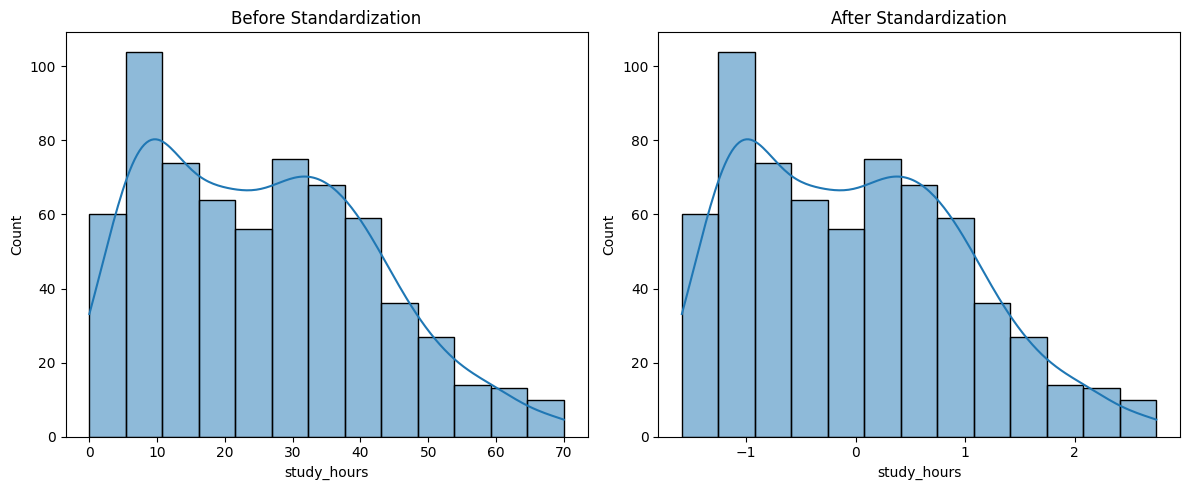

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

original = X_train_orig["study_hours"]
scaled = X_train["study_hours"]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(original, kde=True)
plt.title("Before Standardization")
plt.xlabel("study_hours")

plt.subplot(1,2,2)
sns.histplot(scaled, kde=True)
plt.title("After Standardization")
plt.xlabel("study_hours")

plt.tight_layout()
plt.show()

In [ ]:
range_df = X_train[num_cols].agg(['min', 'max']).T
range_df["range"] = range_df["max"] - range_df["min"]
range_df

,min,max,range
age_capped,-1.722526,4.162896,5.885422
study_hours,-1.585195,2.743686,4.328882
total_empathy,-4.474061,2.138567,6.612628
cog_empathy,-3.234349,2.440979,5.675328
aff_empathy,-3.148155,2.490842,5.638997
motivation,-3.468347,2.365572,5.833918
emotion_rec_acc,-3.437678,2.492317,5.929995


**Need to Discuss whether to keep or not**

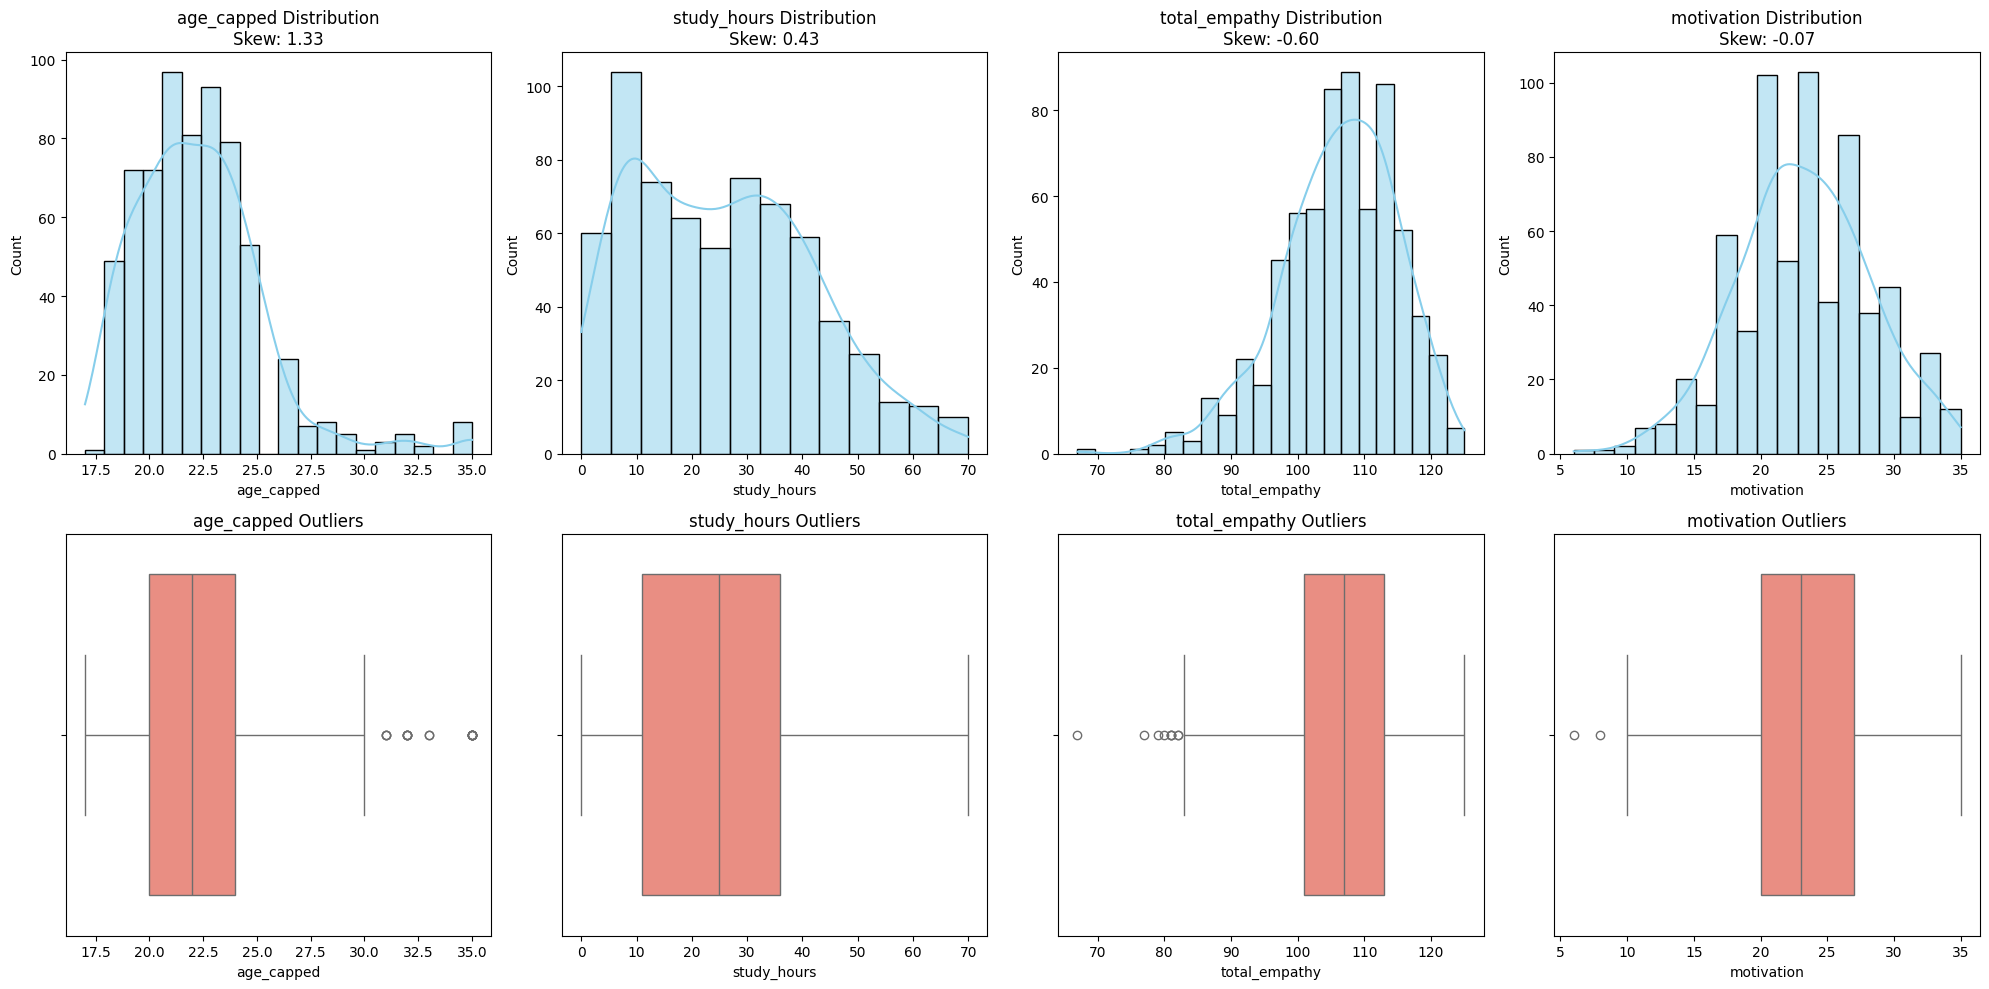

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecting the 4 key features we audited
cols_to_plot = ["age_capped", "study_hours", "total_empathy", "motivation"]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))

for i, col in enumerate(cols_to_plot):

    sns.histplot(X_train_orig[col], kde=True, ax=axes[0, i], color="skyblue")
    axes[0, i].set_title(f"{col} Distribution\nSkew: {X_train_orig[col].skew():.2f}")


    sns.boxplot(x=X_train_orig[col], ax=axes[1, i], color="salmon")
    axes[1, i].set_title(f"{col} Outliers")

plt.tight_layout()
plt.show()

--- APPLYING CONSERVATIVE CAPPING ---
Fixed total_empathy: Values now restricted to range [-2.81, 1.80]
Fixed motivation: Values now restricted to range [-2.34, 2.16]


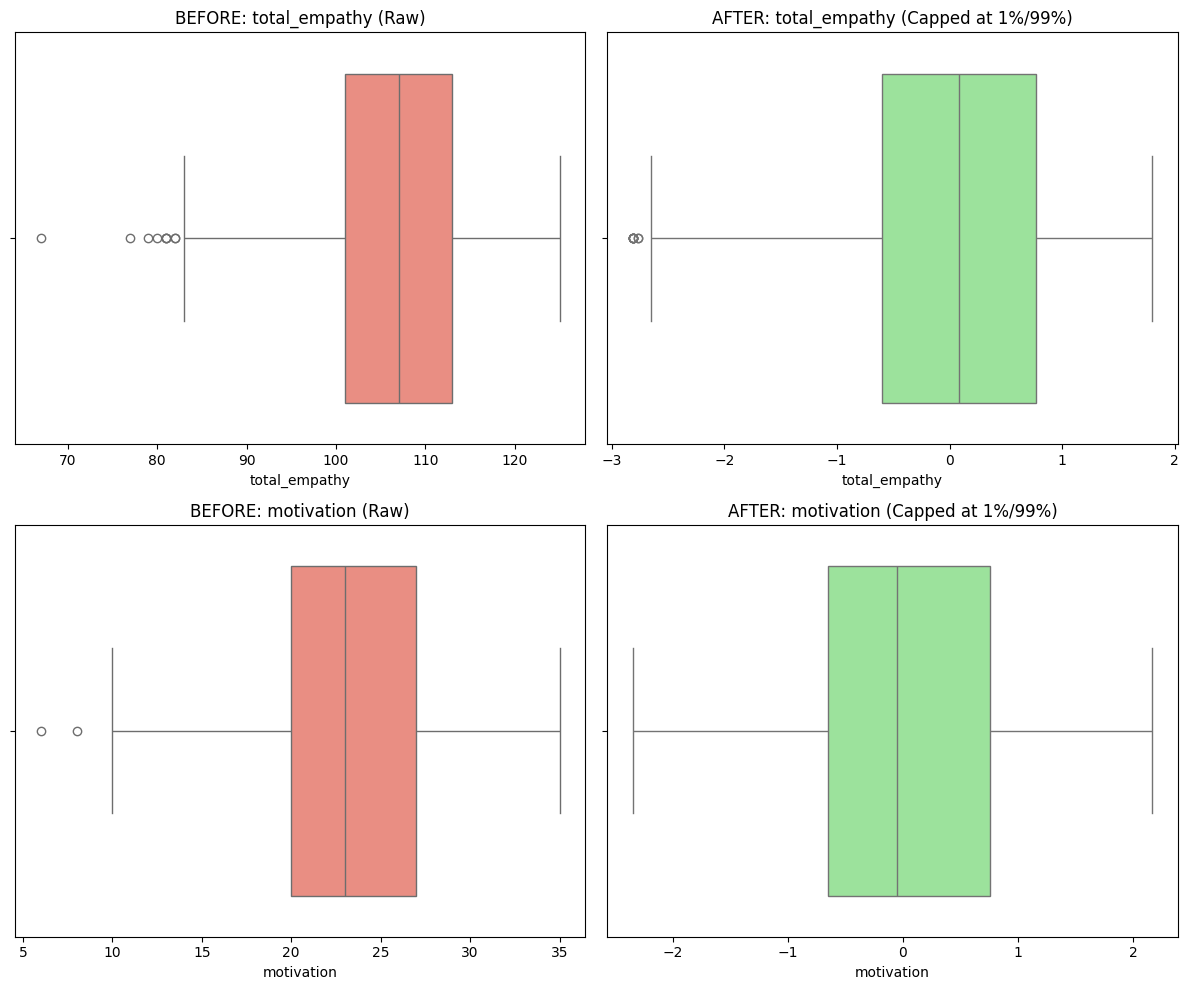

In [ ]:
# 1. Define only the features that need capping based on your audit
features_to_fix = ["total_empathy", "motivation"]

print("--- APPLYING CONSERVATIVE CAPPING ---")
for col in features_to_fix:
    # Calculate limits on Training Data ONLY to avoid data leakage
    lower_limit = X_train[col].quantile(0.01)
    upper_limit = X_train[col].quantile(0.99)

    X_train[col] = X_train[col].clip(lower_limit, upper_limit)
    X_test[col] = X_test[col].clip(lower_limit, upper_limit)

    print(f"Fixed {col}: Values now restricted to range [{lower_limit:.2f}, {upper_limit:.2f}]")


import matplotlib.pyplot as plt
import seaborn as sns

cols_to_show = ["total_empathy", "motivation"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, col in enumerate(cols_to_show):
    # Before
    sns.boxplot(x=X_train_orig[col], ax=axes[i, 0], color="salmon")
    axes[i, 0].set_title(f"BEFORE: {col} (Raw)")

    # After
    sns.boxplot(x=X_train[col], ax=axes[i, 1], color="lightgreen")
    axes[i, 1].set_title(f"AFTER: {col} (Capped at 1%/99%)")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler


num_cols = ["age_capped", "study_hours", "total_empathy", "motivation"]
scaler_raw = StandardScaler()
# Using the original, un-capped data (X_train_orig)
X_scaled_raw = pd.DataFrame(scaler_raw.fit_transform(X_train_orig[num_cols]), columns=num_cols)

range_before_fix = X_scaled_raw.agg(['min', 'max']).T
range_before_fix['range'] = range_before_fix['max'] - range_before_fix['min']

scaler_clean = StandardScaler()
# Using the capped data (X_train) where we applied .clip()
X_scaled_clean = pd.DataFrame(scaler_clean.fit_transform(X_train[num_cols]), columns=num_cols)

range_after_fix = X_scaled_clean.agg(['min', 'max']).T
range_after_fix['range'] = range_after_fix['max'] - range_after_fix['min']

print("--- TABLE 1: WITH RAW OUTLIERS ---")
print(range_before_fix)
print("\n--- TABLE 2: AFTER 1% CAPPING ---")
print(range_after_fix)

--- TABLE 1: WITH RAW OUTLIERS ---
                    min       max     range
age_capped    -1.722526  4.162896  5.885422
study_hours   -1.585195  2.743686  4.328882
total_empathy -4.474061  2.138567  6.612628
motivation    -3.468347  2.365572  5.833918

--- TABLE 2: AFTER 1% CAPPING ---
                    min       max     range
age_capped    -1.722526  4.162896  5.885422
study_hours   -1.585195  2.743686  4.328882
total_empathy -2.867657  1.829475  4.697132
motivation    -2.382825  2.194996  4.577821


**Till Here**

## **Training**

The goal is to use demographic and background features of students to predict their mental wellbeing.

We can train 3 models:
1. one that predicts depression
2. one for predicting anxiety
3. and lastly a multi-output regression model that predicts burn-out scores

In [ ]:
y_train[['depression_score','anxiety_score',"burnout_exhaustion", "burnout_cynicism"]].corr()


,depression_score,anxiety_score,burnout_exhaustion,burnout_cynicism
depression_score,1.000000,0.725637,0.633946,0.458207
anxiety_score,0.725637,1.000000,0.553297,0.365595
burnout_exhaustion,0.633946,0.553297,1.000000,0.522403
burnout_cynicism,0.458207,0.365595,0.522403,1.000000


Depression, anxiety, and burnout are highly correlated. If you include depression and anxiety to predict burnout:

- R² will increase (probably a lot)
- But interpretability changes
- You are partially predicting one distress measure using another

I think it's better if we don't include them, because our research question would be changed.

Possible Models to use:
- random forest
- xgboost
- linear regression
- SVR

## **Classification**

In [ ]:
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

def clf_train(X, y):
    names = [
        "Logistic Regression",
        "Linear SVM",
        "Random Forest",
        "AdaBoost",
    ]

    classifiers = [
        LogisticRegression(max_iter=1000),
        SVC(kernel="linear",  C=0.025, probability=True, random_state=42),
        RandomForestClassifier(
            max_depth=10, n_estimators=50, random_state=42
        ),
        AdaBoostClassifier(random_state=42),
    ]

    # iterate over classifiers
    for name, clf in zip(names, classifiers):
      scores = cross_val_score(
          clf,
          X,
          y,
          cv=5,
          scoring="roc_auc"
      )
      print(f"model: {name}, mean AUC: {scores.mean()}")



In [ ]:
clf_train(X_train, y_train["depression_category"])

model: Logistic Regression, mean AUC: 0.715880587349121
model: Linear SVM, mean AUC: 0.723441088258529
model: Random Forest, mean AUC: 0.694320378093366
model: AdaBoost, mean AUC: 0.713052276046738


based on results: the relationship between features and depression risk is mostly linear.

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train["depression_category"])
odds_ratios = np.exp(model.coef_[0])
pd.Series(odds_ratios, index=X_train.columns).sort_values(ascending=False)

,0
therapy,2.882520
aff_empathy,1.387715
lang_final_Italian,1.126364
study_hours,1.098992
lang_final_Other,1.076291
age_capped,1.057387
lang_final_French,0.979166
motivation,0.974758
emotion_rec_acc,0.946584
age_group_23_plus,0.921923


**without language**

In [ ]:
clf_train(X_train[["age_capped", "year", "sex", "part", "job","study_hours", "health",
                   "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]], y_train["depression_category"])

model: Logistic Regression, mean AUC: 0.7183728367106978
model: Linear SVM, mean AUC: 0.7221923283606768
model: Random Forest, mean AUC: 0.694886283781301
model: AdaBoost, mean AUC: 0.713052276046738


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train[["age_capped", "year", "sex", "part", "job","study_hours", "health",
                   "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]], y_train["depression_category"])
odds_ratios = np.exp(model.coef_[0])
pd.Series(odds_ratios, index=X_train[["age_capped", "year", "sex", "part", "job","study_hours", "health",
                   "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]].columns).sort_values(ascending=False)

,0
therapy,2.873641
aff_empathy,1.385444
study_hours,1.096825
age_capped,1.041561
motivation,0.972635
emotion_rec_acc,0.945335
cog_empathy,0.898499
total_empathy,0.891490
sex,0.869923
job,0.858319


In [ ]:
clf_train(X_train[["total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]], y_train["depression_category"])

model: Logistic Regression, mean AUC: 0.5948307719865518
model: Linear SVM, mean AUC: 0.5762612527787473
model: Random Forest, mean AUC: 0.5541964023258805
model: AdaBoost, mean AUC: 0.5788961827818706


**after grouping age**

In [ ]:
clf_train(X_train[["age_group_23_plus", "year", "sex", "part", "job","study_hours", "health",
                   "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]], y_train["depression_category"])

model: Logistic Regression, mean AUC: 0.719678044221124
model: Linear SVM, mean AUC: 0.72656701833514
model: Random Forest, mean AUC: 0.6927509140012125
model: AdaBoost, mean AUC: 0.7156724683544304


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train[["age_group_23_plus", "year", "sex", "part", "job","study_hours", "health",
                   "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]], y_train["depression_category"])
odds_ratios = np.exp(model.coef_[0])
pd.Series(odds_ratios, index=X_train[["age_group_23_plus", "year", "sex", "part", "job","study_hours", "health",
                   "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]].columns).sort_values(ascending=False)

,0
therapy,2.863209
aff_empathy,1.383256
study_hours,1.099867
age_group_23_plus,0.986965
motivation,0.972948
emotion_rec_acc,0.941642
cog_empathy,0.897715
total_empathy,0.893110
job,0.870866
sex,0.870616


In [ ]:
import statsmodels.api as sm
X_sm = sm.add_constant(X_train[["age_group_23_plus", "year", "sex", "part", "job","study_hours", "health",
                   "therapy", "total_empathy", "cog_empathy","aff_empathy",
                   "motivation", "emotion_rec_acc"]])
X_sm = X_sm.astype(float)
model_sm = sm.Logit(y_train["depression_category"], X_sm).fit()
print(model_sm.summary())

Optimization terminated successfully.
         Current function value: 0.572390
         Iterations 6


AttributeError: module 'scipy.stats' has no attribute 'distributions'